# 🔍 Store Sales Time Series Forecasting — Exploratory Data Analysis (EDA)

> 📌 **Часть 1 из 2** • Следующий этап: [`02_modeling_store_sales_forecasting.ipynb`](02_modeling_store_sales_forecasting.ipynb)  
> 🌐 **Оригинальный датасет**: [Kaggle — Store Sales Time Series Forecasting](https://www.kaggle.com/competitions/store-sales-time-series-forecasting)

---

## 🛒 1️⃣ Цель проекта

Прогнозирование дневных продаж в магазинах **Corporación Favorita** (крупнейшая сеть супермаркетов Эквадора).

- **Задача**: предсказать `unit sales` для **тысяч товаров** в **десятках магазинов**.
- **Бизнес-цель**: помочь ритейлеру:
  - ✅ Оптимально планировать закупки,
  - ✅ Минимизировать избыточные запасы и потери от просрочки,
  - ✅ Избежать дефицита популярных товаров,
  - ✅ Повысить удовлетворённость клиентов.

---

## 🌍 2️⃣ Контекст

Прогнозирование спроса — **одна из ключевых задач ритейла**.  
Ошибки дорого обходятся:

- 📉 **Слишком много товара** → просрочка, списания, убытки.  
- 📈 **Слишком мало товара** → упущенные продажи, разочарованные клиенты.

Особенности данных:
- Несколько **магазинов с разной географией** (город, регион, тип),
- **Сезонность** (праздники, выходные, начало/конец месяца),
- **Маркетинговые акции** (`onpromotion`) — сильный драйвер продаж.

---

## 📏 3️⃣ Метрика оценки: RMSLE

Используется **Root Mean Squared Logarithmic Error (RMSLE)** — стандарт для этой задачи на Kaggle.

✅ **Почему RMSLE?**
- Снижает влияние **выбросов** (например, суперпопулярный товар с продажами в 10 000+),
- Фокусируется на **относительной (процентной) ошибке**, а не абсолютной,
- Лучше отражает **бизнес-воздействие**: ошибка в 10 единиц при продажах 100 — критична; при продажах 10 000 — нет.

---

## 📅 4️⃣ Уровень прогноза

- Прогноз строится **на уровне одного дня** для каждой **уникальной комбинации**:  
  `(магазин, товар, дата)`.
- При необходимости результаты можно **агрегировать** до недельного или месячного уровня для стратегического анализа.

---

## 💡 5️⃣ Потенциальное влияние

- **Снижение операционных издержек** за счёт точного управления запасами.
- **Рост выручки** — товар всегда есть в наличии в пик спроса.
- **Масштабируемость**: подход применим к новым магазинам, товарам и даже другим ритейлерам.

> 🔜 В следующем ноутбуке мы построим **модель, готовую к инференсу в реальном времени**, с сохранением метаданных и возможностью будущего деплоя через Streamlit.

In [ ]:
# Установка пакетов
!pip install -q \
    numpy \
    pandas \
    matplotlib \
    seaborn \
    statsmodels \
    scipy \
    lightgbm \
    catboost \
    xgboost \
    tsfresh \
    holidays \
    prophet \
    python-dateutil

In [ ]:
# ----------------------------
# 🔢 Основные библиотеки
# ----------------------------
import numpy as np
import pandas as pd

# ----------------------------
# 📅 Работа с датами
# ----------------------------
import datetime as dt
from dateutil.relativedelta import relativedelta

# ----------------------------
# 📊 Визуализация
# ----------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# 📈 Временные ряды и статистика
# ----------------------------
import statsmodels.api as sm
import statsmodels.tsa.api as tsa
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss

# ----------------------------
# 🤖 Модели машинного обучения
# ----------------------------
from catboost import CatBoostRegressor, Pool
import lightgbm as lgb
import xgboost as xgb
from prophet import Prophet

# ----------------------------
# 🛠 Метрики, препроцессинг, пайплайны
# ----------------------------
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans

# ----------------------------
# 🧩 Дополнительные инструменты
# ----------------------------
from tsfresh import extract_features
import holidays
import scipy.stats as stats

# ----------------------------
# ⚙️ Настройки и утилиты
# ----------------------------
import warnings
warnings.filterwarnings("ignore")

# Настройки отображения pandas
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.expand_frame_repr", False)
pd.set_option("display.float_format", "{:.2f}".format)

from IPython.display import display

## Загрузка исходных данных

In [ ]:
df_sales = pd.read_csv("/content/drive/MyDrive/portfolio-projects/store_sales_time_series_forecasting/data/train.csv.zip")
df_sales.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.00,0
1,1,2013-01-01,1,BABY CARE,0.00,0
2,2,2013-01-01,1,BEAUTY,0.00,0
3,3,2013-01-01,1,BEVERAGES,0.00,0
4,4,2013-01-01,1,BOOKS,0.00,0


In [ ]:
df_stores =pd.read_csv("/content/drive/MyDrive/portfolio-projects/store_sales_time_series_forecasting/data/stores.csv")
df_stores.head()

,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


In [ ]:
df_holidays= pd.read_csv("/content/drive/MyDrive/portfolio-projects/store_sales_time_series_forecasting/data/holidays_events.csv")
df_holidays.head()

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [ ]:
set(df_sales['store_nbr']).issubset(df_stores['store_nbr'])

True

In [ ]:
set(df_sales['date']).issubset(df_holidays['date'])

False

In [ ]:
def preview_df(df, name: str):
    print(f"\n===== {name}: HEAD (5) =====")
    display(df.head())

    print(f"\n===== {name}: TAIL (5) =====")
    display(df.tail())

    print(f"\n===== {name}: SAMPLE (5) =====")
    display(df.sample(5, random_state=42))


date — дата   
store_nbr — номер магазина    
family — категория товара (товарная группа)    
sales — продажи (количество/объём продаж)   
onpromotion — находится в акции / промо (флаг: участвует ли товар в скидке)

In [ ]:
preview_df(df_sales, "df_sales")


===== df_sales: HEAD (5) =====


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.00,0
1,1,2013-01-01,1,BABY CARE,0.00,0
2,2,2013-01-01,1,BEAUTY,0.00,0
3,3,2013-01-01,1,BEVERAGES,0.00,0
4,4,2013-01-01,1,BOOKS,0.00,0



===== df_sales: TAIL (5) =====


,id,date,store_nbr,family,sales,onpromotion
3000883,3000883,2017-08-15,9,POULTRY,438.13,0
3000884,3000884,2017-08-15,9,PREPARED FOODS,154.55,1
3000885,3000885,2017-08-15,9,PRODUCE,2419.73,148
3000886,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.00,8
3000887,3000887,2017-08-15,9,SEAFOOD,16.00,0



===== df_sales: SAMPLE (5) =====


,id,date,store_nbr,family,sales,onpromotion
2483653,2483653,2016-10-28,46,CLEANING,2576.00,61
2761877,2761877,2017-04-03,52,DAIRY,0.00,0
1217988,1217988,2014-11-16,33,MEATS,357.35,2
1231938,1231938,2014-11-24,25,HOME AND KITCHEN I,5.00,0
528175,528175,2013-10-24,29,EGGS,0.00,0


In [ ]:
preview_df(df_stores, "df_stores")


===== df_stores: HEAD (5) =====


,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4



===== df_stores: TAIL (5) =====


,store_nbr,city,state,type,cluster
49,50,Ambato,Tungurahua,A,14
50,51,Guayaquil,Guayas,A,17
51,52,Manta,Manabi,A,11
52,53,Manta,Manabi,D,13
53,54,El Carmen,Manabi,C,3



===== df_stores: SAMPLE (5) =====


,store_nbr,city,state,type,cluster
19,20,Quito,Pichincha,B,6
49,50,Ambato,Tungurahua,A,14
48,49,Quito,Pichincha,A,11
12,13,Latacunga,Cotopaxi,C,15
44,45,Quito,Pichincha,A,11


store_nbr — номер магазина    
city — город    
state — штат / регион    
type — тип магазина    
cluster — кластер (группа магазинов с похожими характеристиками)

In [ ]:
pd.crosstab(df_stores['type'], df_stores['cluster'])

cluster,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
type,,,,,,,,,,,,,,,,,
A,0,0,0,0,1,0,0,0,0,0,3,0,0,4,0,0,1
B,0,0,0,0,0,6,0,0,0,1,0,0,0,0,0,1,0
C,0,0,7,0,0,0,2,0,0,0,0,1,0,0,5,0,0
D,3,2,0,3,0,0,0,3,2,1,0,0,4,0,0,0,0
E,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0


In [ ]:
preview_df(df_holidays, "df_holidays")


===== df_holidays: HEAD (5) =====


,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False



===== df_holidays: TAIL (5) =====


,date,type,locale,locale_name,description,transferred
345,2017-12-22,Additional,National,Ecuador,Navidad-3,False
346,2017-12-23,Additional,National,Ecuador,Navidad-2,False
347,2017-12-24,Additional,National,Ecuador,Navidad-1,False
348,2017-12-25,Holiday,National,Ecuador,Navidad,False
349,2017-12-26,Additional,National,Ecuador,Navidad+1,False



===== df_holidays: SAMPLE (5) =====


,date,type,locale,locale_name,description,transferred
157,2014-12-26,Additional,National,Ecuador,Navidad+1,False
341,2017-12-08,Holiday,Local,Loja,Fundacion de Loja,False
315,2017-06-25,Holiday,Regional,Imbabura,Provincializacion de Imbabura,False
234,2016-04-30,Event,National,Ecuador,Terremoto Manabi+14,False
155,2014-12-25,Holiday,National,Ecuador,Navidad,False


date — дата    
type — тип события (например: праздник, мост, рабочий день)    
locale — уровень локализации события (национальный / региональный / локальный)     
locale_name — название конкретного региона или локали    
description — описание события    
transferred — перенесённый праздник (флаг: был ли праздник перенесён на другую дату)

In [ ]:
df_sales = df_sales.drop(columns=["id"])

In [ ]:
def dataset_report(df, name: str):
    print(f"\n===== {name}: INFO =====")
    df.info()

    print(f"\n===== {name}: DESCRIBE =====")
    display(df.describe())

dataset_report(df_sales, "df_sales")
dataset_report(df_holidays, "df_holidays")
dataset_report(df_stores, "df_stores")



===== df_sales: INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 5 columns):
 #   Column       Dtype  
---  ------       -----  
 0   date         object 
 1   store_nbr    int64  
 2   family       object 
 3   sales        float64
 4   onpromotion  int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 114.5+ MB

===== df_sales: DESCRIBE =====


,store_nbr,sales,onpromotion
count,3000888.00,3000888.00,3000888.00
mean,27.50,357.78,2.60
std,15.59,1102.00,12.22
min,1.00,0.00,0.00
25%,14.00,0.00,0.00
50%,27.50,11.00,0.00
75%,41.00,195.85,0.00
max,54.00,124717.00,741.00



===== df_holidays: INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         350 non-null    object
 1   type         350 non-null    object
 2   locale       350 non-null    object
 3   locale_name  350 non-null    object
 4   description  350 non-null    object
 5   transferred  350 non-null    bool  
dtypes: bool(1), object(5)
memory usage: 14.1+ KB

===== df_holidays: DESCRIBE =====


,date,type,locale,locale_name,description,transferred
count,350,350,350,350,350,350
unique,312,6,3,24,103,2
top,2014-06-25,Holiday,National,Ecuador,Carnaval,False
freq,4,221,174,174,10,338



===== df_stores: INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   store_nbr  54 non-null     int64 
 1   city       54 non-null     object
 2   state      54 non-null     object
 3   type       54 non-null     object
 4   cluster    54 non-null     int64 
dtypes: int64(2), object(3)
memory usage: 2.2+ KB

===== df_stores: DESCRIBE =====


,store_nbr,cluster
count,54.00,54.00
mean,27.50,8.48
std,15.73,4.69
min,1.00,1.00
25%,14.25,4.00
50%,27.50,8.50
75%,40.75,13.00
max,54.00,17.00


##  Диагностика качества данных

In [ ]:
def check_shape_all(**dfs):
    print("=== SHAPE CHECK ===")
    for name, df in dfs.items():
        print(f"{name}: {df.shape}")
    print()


def check_duplicates_all(show=False, **dfs):
    print("=== DUPLICATE CHECK ===")
    for name, df in dfs.items():
        dup_count = df.duplicated().sum()
        print(f"{name}: {dup_count} duplicates")

        if show and dup_count > 0:
            display(df[df.duplicated()])
    print()


def check_unique_values_all(max_unique=20, **dfs):
    print("=== UNIQUE VALUES CHECK ===")
    for name, df in dfs.items():
        print(f"\n--- {name} ---")
        for col in df.columns:
            uniq_count = df[col].nunique()
            print(f"{col}: {uniq_count} unique")

            if uniq_count <= max_unique:
                print("Values:", df[col].unique())
        print()
    print()


def check_missing_all(**dfs):
    print("=== MISSING VALUES CHECK ===")
    for name, df in dfs.items():
        missing = df.isna().sum()
        total_missing = missing.sum()
        print(f"\n{name}: total missing = {total_missing}")

        if total_missing > 0:
            print(missing[missing > 0])
    print()

check_shape_all(
    df_sales=df_sales,
    df_holidays=df_holidays,
    df_stores=df_stores
)

check_duplicates_all(
    df_sales=df_sales,
    df_holidays=df_holidays,
    df_stores=df_stores
)

check_unique_values_all(
    df_sales=df_sales,
    df_holidays=df_holidays,
    df_stores=df_stores
)

check_missing_all(
    df_sales=df_sales,
    df_holidays=df_holidays,
    df_stores=df_stores
)


=== SHAPE CHECK ===
df_sales: (3000888, 5)
df_holidays: (350, 6)
df_stores: (54, 5)

=== DUPLICATE CHECK ===
df_sales: 0 duplicates
df_holidays: 0 duplicates
df_stores: 0 duplicates

=== UNIQUE VALUES CHECK ===

--- df_sales ---
date: 1684 unique
store_nbr: 54 unique
family: 33 unique
sales: 379610 unique
onpromotion: 362 unique


--- df_holidays ---
date: 312 unique
type: 6 unique
Values: ['Holiday' 'Transfer' 'Additional' 'Bridge' 'Work Day' 'Event']
locale: 3 unique
Values: ['Local' 'Regional' 'National']
locale_name: 24 unique
description: 103 unique
transferred: 2 unique
Values: [False  True]


--- df_stores ---
store_nbr: 54 unique
city: 22 unique
state: 16 unique
Values: ['Pichincha' 'Santo Domingo de los Tsachilas' 'Cotopaxi' 'Chimborazo'
 'Imbabura' 'Bolivar' 'Pastaza' 'Tungurahua' 'Guayas' 'Santa Elena'
 'Los Rios' 'Azuay' 'Loja' 'El Oro' 'Esmeraldas' 'Manabi']
type: 5 unique
Values: ['D' 'B' 'C' 'E' 'A']
cluster: 17 unique
Values: [13  8  9  4  6 15  7  3 12 16  1 10  2  5 1

### Функция первичной проверки артефактов

In [ ]:
def check_artifacts_all(**dfs):
    print("=== ARTIFACT CHECK ===")

    for name, df in dfs.items():
        print(f"\n--- {name} ---")

        # 1. Значения < 0
        numeric_cols = df.select_dtypes(include=["number"]).columns
        neg_mask = (df[numeric_cols] < 0).any()
        neg_cols = neg_mask[neg_mask].index.tolist()

        if neg_cols:
            print("Negative values found in columns:", neg_cols)
        else:
            print("No negative values.")

        # 2. Пустые строки или строки из пробелов
        str_cols = df.select_dtypes(include=["object"]).columns
        empty_mask = df[str_cols].apply(lambda s: s.astype(str).str.strip().eq(""))
        empty_cols = empty_mask.any()

        if empty_cols.any():
            print("Empty-string artifacts found in columns:", empty_cols[empty_cols].index.tolist())
        else:
            print("No empty-string artifacts.")

        # 3. Строковые NULL / NaN
        null_strings_mask = df[str_cols].apply(
            lambda s: s.astype(str).str.lower().isin(["null", "nan", "none"])
        )
        null_cols = null_strings_mask.any()

        if null_cols.any():
            print("String NULL/NAN artifacts found in columns:", null_cols[null_cols].index.tolist())
        else:
            print("No string NULL/NAN artifacts.")

    print("\n=== CHECK COMPLETE ===")

check_artifacts_all(
    df_sales=df_sales,
    df_holidays=df_holidays,
    df_stores=df_stores
)


=== ARTIFACT CHECK ===

--- df_sales ---
No negative values.
No empty-string artifacts.
No string NULL/NAN artifacts.

--- df_holidays ---
No negative values.
No empty-string artifacts.
No string NULL/NAN artifacts.

--- df_stores ---
No negative values.
No empty-string artifacts.
No string NULL/NAN artifacts.

=== CHECK COMPLETE ===


In [ ]:
# Сколько уникальных дат в df_holidays
print(df_holidays['date'].nunique())

# Проверка дублирования по ключу
dups = df_holidays.duplicated(subset=['date'], keep=False)
print("Rows with duplicate date in df_holidays:", dups.sum())


312
Rows with duplicate date in df_holidays: 69


In [ ]:
# Переименовываем признаки с одинаковыми именами перед merge

df_stores.rename(columns={'type': 'store_type'}, inplace=True)
df_holidays.rename(columns={'type': 'holiday_type'}, inplace=True)

In [ ]:
# Оставляем только одну запись на дату
df_holidays = df_holidays.drop_duplicates(subset=['date'])


## Объединение таблиц


In [ ]:
# Преобразуем даты в datetime
df_sales['date'] = pd.to_datetime(df_sales['date'])
df_holidays['date'] = pd.to_datetime(df_holidays['date'])

# Объединяем df_sales с df_stores по store_nbr
merged_data = df_sales.merge(df_stores, on='store_nbr', how='left')

# Объединяем df с df_holidays по date
merged_data = merged_data.merge(df_holidays, on='date', how='left')

In [ ]:
# Контрольные точки после merge

print("===== SHAPE =====")
print(merged_data.shape)

print("\n===== HEAD (первые 5 строк) =====")
print(merged_data.head())

print("\n===== TAIL (последние 5 строк) =====")
print(merged_data.tail())

print("\n===== DUPLICATES =====")
dup_count = merged_data.duplicated().sum()
print(f"Количество дубликатов: {dup_count}")

print("\n===== MISSING VALUES =====")
missing_abs = merged_data.isna().sum()
missing_rel = (missing_abs / len(merged_data) * 100).round(2)
missing_table = pd.DataFrame({
    'Missing (abs)': missing_abs,
    'Missing (%)': missing_rel
})
missing_table = missing_table[missing_table['Missing (abs)'] > 0]
display(missing_table)

print("\n===== DTYPE =====")
print(merged_data.dtypes)

print("\n===== DESCRIBE =====")
print(merged_data.describe())

# Контроль категориальных признаков
cat_cols = merged_data.select_dtypes(include='object')

print("===== Categorical Columns Describe =====")
display(cat_cols.describe())


===== SHAPE =====
(3000888, 14)

===== HEAD (первые 5 строк) =====
        date  store_nbr      family  sales  onpromotion   city      state store_type  cluster holiday_type    locale locale_name         description transferred
0 2013-01-01          1  AUTOMOTIVE   0.00            0  Quito  Pichincha          D       13      Holiday  National     Ecuador  Primer dia del ano       False
1 2013-01-01          1   BABY CARE   0.00            0  Quito  Pichincha          D       13      Holiday  National     Ecuador  Primer dia del ano       False
2 2013-01-01          1      BEAUTY   0.00            0  Quito  Pichincha          D       13      Holiday  National     Ecuador  Primer dia del ano       False
3 2013-01-01          1   BEVERAGES   0.00            0  Quito  Pichincha          D       13      Holiday  National     Ecuador  Primer dia del ano       False
4 2013-01-01          1       BOOKS   0.00            0  Quito  Pichincha          D       13      Holiday  National     Ecuador

,Missing (abs),Missing (%)
holiday_type,2551824,85.04
locale,2551824,85.04
locale_name,2551824,85.04
description,2551824,85.04
transferred,2551824,85.04



===== DTYPE =====
date            datetime64[ns]
store_nbr                int64
family                  object
sales                  float64
onpromotion              int64
city                    object
state                   object
store_type              object
cluster                  int64
holiday_type            object
locale                  object
locale_name             object
description             object
transferred             object
dtype: object

===== DESCRIBE =====
                                date  store_nbr      sales  onpromotion    cluster
count                        3000888 3000888.00 3000888.00   3000888.00 3000888.00
mean   2015-04-24 08:27:04.703088384      27.50     357.78         2.60       8.48
min              2013-01-01 00:00:00       1.00       0.00         0.00       1.00
25%              2014-02-26 18:00:00      14.00       0.00         0.00       4.00
50%              2015-04-24 12:00:00      27.50      11.00         0.00       8.50
75%          

,family,city,state,store_type,holiday_type,locale,locale_name,description,transferred
count,3000888,3000888,3000888,3000888,449064,449064,449064,449064,449064
unique,33,22,16,5,6,3,23,93,2
top,AUTOMOTIVE,Quito,Pichincha,D,Holiday,National,Ecuador,Carnaval,False
freq,90936,1000296,1055868,1000296,270864,242352,242352,17820,433026


In [ ]:
# Сколько строк реально содержат праздник
holiday_rows = merged_data['holiday_type'].notna().sum()
print(f"Rows with holiday info: {holiday_rows}")

# Процент заполненных vs. пустых строк
filled_pct = merged_data['holiday_type'].notna().mean() * 100
print(f"Percentage of rows with holiday info: {filled_pct:.2f}%")

Rows with holiday info: 449064
Percentage of rows with holiday info: 14.96%


In [ ]:
merged_data.groupby('date')['holiday_type'].first().value_counts(dropna=False)


,count
holiday_type,
None,1432
Holiday,152
Event,49
Additional,36
Transfer,8
Work Day,4
Bridge,3


Что это значит:

None — дата есть в merged dataset, но в df_holidays нет записи о празднике. Обычно это обычные рабочие дни.

Holiday — это обычные праздники (например, официальные выходные).

Event — это специальные события, которые могут быть локальными.

Additional — дополнительные праздничные дни, например, перенос выходного.

Transfer — переносы рабочих дней/выходных (например, с понедельника на субботу).

Work Day — дополнительные рабочие дни (например, компенсация за праздничные выходные).

Bridge — “связующие дни” между праздниками и выходными (часто используют в календарях некоторых стран).

Вывод по этапу объединения таблиц

Что сделано:

* Удалена колонка id из df_sales, так как она не несёт аналитической ценности.

* Переименование колонок с одинаковыми именами (type → store_type, holiday_type) для избежания конфликтов при merge.

* Удаление дубликатов в df_holidays по дате (69 строк), чтобы merge не умножал строки и dataset остался корректным для анализа.

Объединение таблиц:

* df_sales + df_stores по ключу store_nbr

* результат + df_holidays по ключу date    

Пропуски после объединения:   

До объединения пропусков в исходных таблицах не было.

После объединения появились пропуски в колонках, связанных с праздниками: holiday_type, locale, locale_name, description, transferred — примерно 85% строк содержат NaN.

Это логично и ожидаемо, так как df_holidays содержит информацию только для ограниченного числа дат.

Пропуски структурированные, отражают отсутствие праздников в эти дни и не являются ошибкой данных.   

Признаки и типы данных после объединения:

| Признак         | Тип данных      |
|-----------------|----------------|
| date            | datetime64[ns] |
| store_nbr       | int64          |
| family          | object         |
| sales           | float64        |
| onpromotion     | int64          |
| city            | object         |
| state           | object         |
| store_type      | object         |
| cluster         | int64          |
| holiday_type    | object         |
| locale          | object         |
| locale_name     | object         |
| description     | object         |
| transferred     | object         |


На данном этапе получен структурированный, чистый и готовый к анализу dataset, где:

* устранены дубликаты и конфликтующие имена колонок,

* удалена ненужная колонка id,

* исключены 69 дублирующихся строк по дате в df_holidays,

* merge выполнен по ключевым полям (store_nbr и date).

In [ ]:
# Сохраняем объединённый dataset в CSV
merged_data.to_csv('/content/drive/MyDrive/portfolio-projects/store_sales_time_series_forecasting/notebook/merged_data.csv', index=False)

# Проверка
print("Dataset успешно сохранён по указанному пути!")


Dataset успешно сохранён по указанному пути!


## Сохранённый dataset

In [93]:
data = pd.read_csv("/content/drive/MyDrive/portfolio-projects/store_sales_time_series_forecasting/notebook/merged_data.csv")

In [94]:
df = data.copy()
df.head()

,date,store_nbr,family,sales,onpromotion,city,state,store_type,cluster,holiday_type,locale,locale_name,description,transferred
0,2013-01-01,1,AUTOMOTIVE,0.00,0,Quito,Pichincha,D,13,Holiday,National,Ecuador,Primer dia del ano,False
1,2013-01-01,1,BABY CARE,0.00,0,Quito,Pichincha,D,13,Holiday,National,Ecuador,Primer dia del ano,False
2,2013-01-01,1,BEAUTY,0.00,0,Quito,Pichincha,D,13,Holiday,National,Ecuador,Primer dia del ano,False
3,2013-01-01,1,BEVERAGES,0.00,0,Quito,Pichincha,D,13,Holiday,National,Ecuador,Primer dia del ano,False
4,2013-01-01,1,BOOKS,0.00,0,Quito,Pichincha,D,13,Holiday,National,Ecuador,Primer dia del ano,False


## Предмодельный анализ временных и календарных паттернов

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 14 columns):
 #   Column        Dtype  
---  ------        -----  
 0   date          object 
 1   store_nbr     int64  
 2   family        object 
 3   sales         float64
 4   onpromotion   int64  
 5   city          object 
 6   state         object 
 7   store_type    object 
 8   cluster       int64  
 9   holiday_type  object 
 10  locale        object 
 11  locale_name   object 
 12  description   object 
 13  transferred   object 
dtypes: float64(1), int64(3), object(10)
memory usage: 320.5+ MB


In [96]:
df['date'] = pd.to_datetime(df['date'])

# Создаем временные признаки (базовые)
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.dayofweek  # 0=понедельник
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)  # 5 и 6 = суб, вс
df['week_of_year'] = df['date'].dt.isocalendar().week

# Для сезонности: день в году (1-365)
df['day_of_year'] = df['date'].dt.dayofyear

print(df.dtypes['date'])
df[['date', 'year', 'month', 'day', 'day_of_week', 'is_weekend', 'week_of_year', 'day_of_year']].sample(5)

datetime64[ns]


,date,year,month,day,day_of_week,is_weekend,week_of_year,day_of_year
2343162,2016-08-10,2016,8,10,2,0,32,223
2164815,2016-05-02,2016,5,2,0,0,18,123
2985851,2017-08-07,2017,8,7,0,0,32,219
1168480,2014-10-19,2014,10,19,6,1,42,292
2673658,2017-02-13,2017,2,13,0,0,7,44


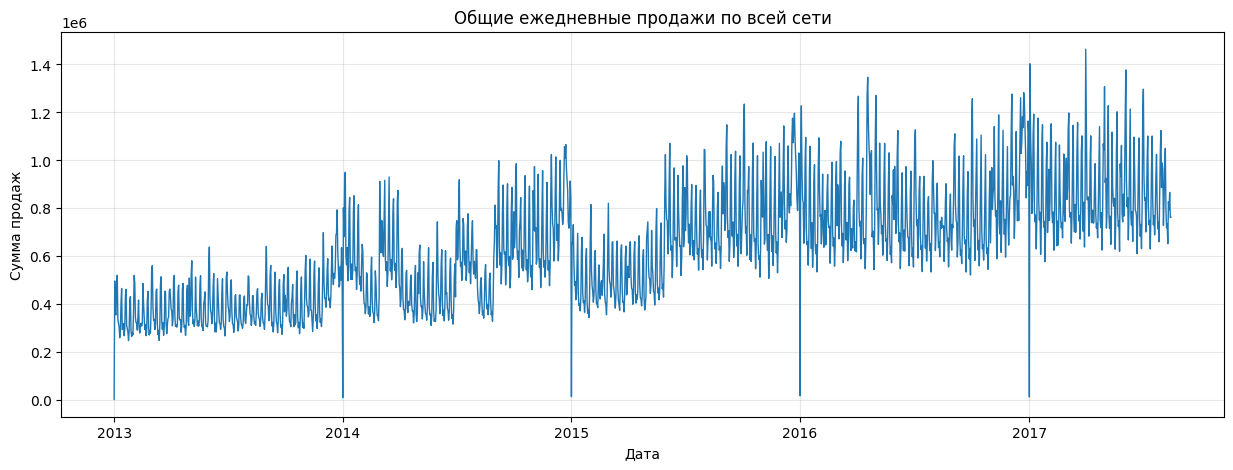

In [97]:
# Агрегируем продажи по ВСЕЙ сети по дням
daily_sales = df.groupby('date')['sales'].sum()

plt.figure(figsize=(15, 5))
plt.plot(daily_sales.index, daily_sales.values, linewidth=1)
plt.title('Общие ежедневные продажи по всей сети')
plt.xlabel('Дата')
plt.ylabel('Сумма продаж')
plt.grid(True, alpha=0.3)
plt.show()

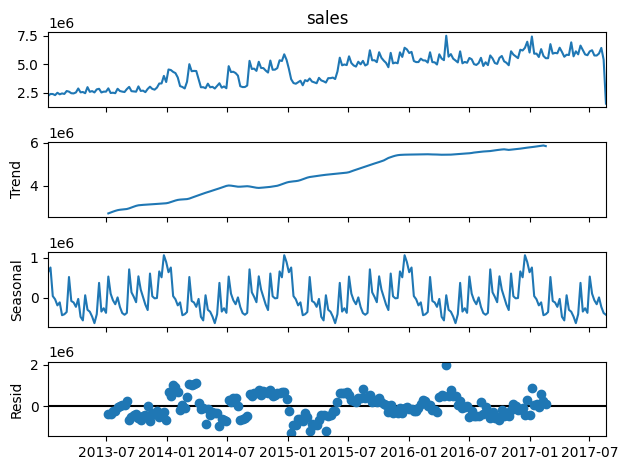

In [98]:
# Агрегируем по неделям
weekly_sales = df.groupby(pd.Grouper(key='date', freq='W'))['sales'].sum()

# Разложение
result = seasonal_decompose(weekly_sales, model='additive', period=52)
result.plot()
plt.show()

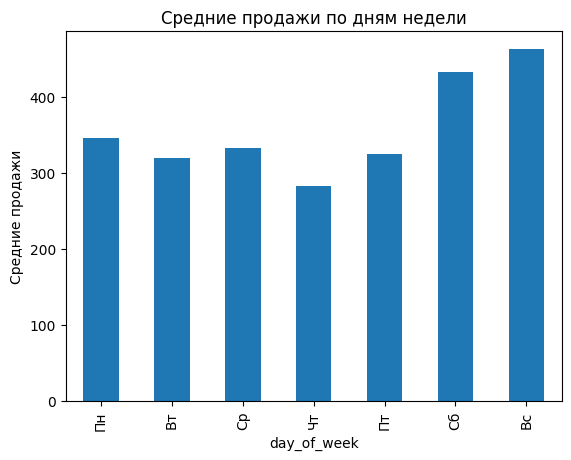

In [99]:
# Средние продажи по дням недели
daily_avg = df.groupby('day_of_week')['sales'].mean()
daily_avg.plot(kind='bar', title='Средние продажи по дням недели')
plt.xticks(range(7), ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'])
plt.ylabel('Средние продажи')
plt.show()

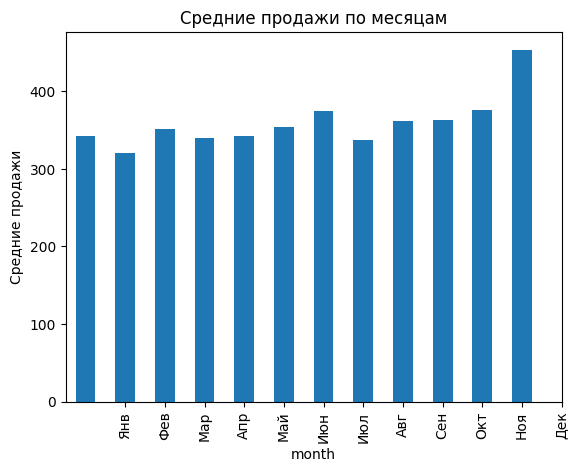

In [100]:
# Средние продажи по месяцам
monthly_avg = df.groupby('month')['sales'].mean()
monthly_avg.plot(kind='bar', title='Средние продажи по месяцам')
plt.xticks(range(1,13), ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек'])
plt.ylabel('Средние продажи')
plt.show()

In [101]:
# Признак "конец месяца" - часто всплеск продаж
df['is_month_end'] = df['date'].dt.is_month_end.astype(int)
df['is_month_start'] = df['date'].dt.is_month_start.astype(int)

Средние продажи:
is_month_end
0   357.14
1   376.50
Name: sales, dtype: float64


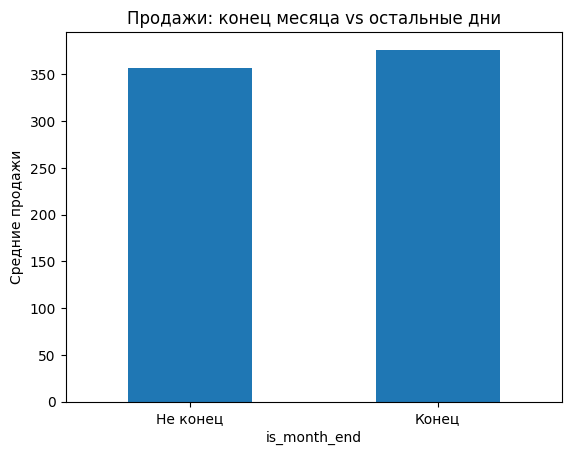

In [102]:
# Конец месяца
month_end_effect = df.groupby('is_month_end')['sales'].mean()
print("Средние продажи:")
print(month_end_effect)

month_end_effect.plot(kind='bar', title='Продажи: конец месяца vs остальные дни')
plt.xticks([0, 1], ['Не конец', 'Конец'], rotation=0)
plt.ylabel('Средние продажи')
plt.show()

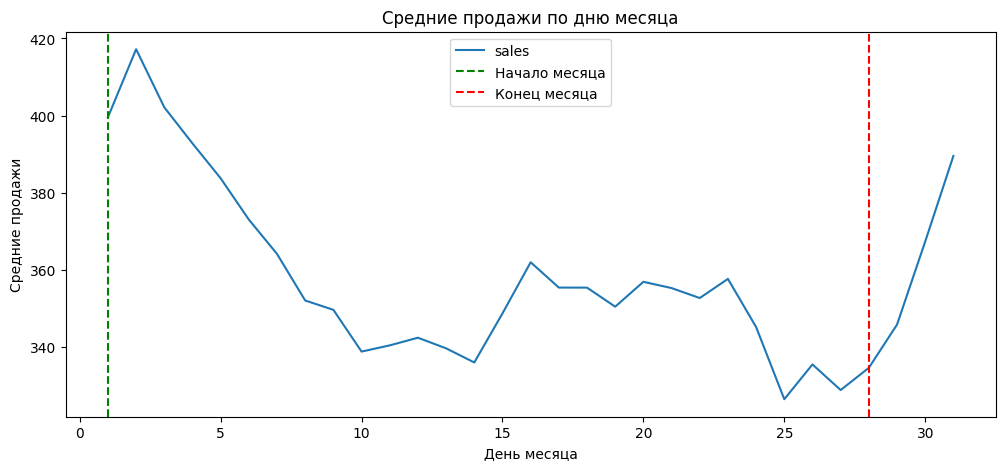

In [103]:
# Средние продажи по дню месяца (1–31)
df.groupby('day')['sales'].mean().plot(
    title='Средние продажи по дню месяца',
    figsize=(12, 5)
)
plt.xlabel('День месяца')
plt.ylabel('Средние продажи')
plt.axvline(1, color='green', linestyle='--', label='Начало месяца')
plt.axvline(28, color='red', linestyle='--', label='Конец месяца')
plt.legend()
plt.show()

In [104]:
# Создаем основной бинарный признак
df['is_holiday'] = df['holiday_type'].notna().astype(int)

# Cоздаем признаки типа праздника (заполняем 0 для NaN)
df['is_national_holiday'] = (df['locale'] == 'National').fillna(0).astype(int)
df['is_regional_holiday'] = (df['locale'] == 'Regional').fillna(0).astype(int)
df['is_local_holiday'] = (df['locale'] == 'Local').fillna(0).astype(int)

# Удаляем исходные праздничные колонки
holiday_cols = ['holiday_type', 'locale', 'locale_name', 'description', 'transferred']
df = df.drop(columns=holiday_cols)

print(df[['is_holiday', 'is_national_holiday']].sum())
print(df.isnull().sum())

is_holiday             449064
is_national_holiday    242352
dtype: int64
date                   0
store_nbr              0
family                 0
sales                  0
onpromotion            0
city                   0
state                  0
store_type             0
cluster                0
year                   0
month                  0
day                    0
day_of_week            0
is_weekend             0
week_of_year           0
day_of_year            0
is_month_end           0
is_month_start         0
is_holiday             0
is_national_holiday    0
is_regional_holiday    0
is_local_holiday       0
dtype: int64


is_holiday
0   352.16
1   389.69
Name: sales, dtype: float64


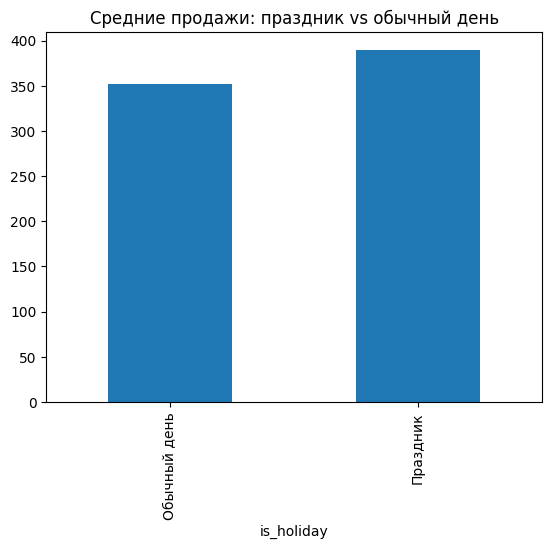

In [105]:
print(df.groupby('is_holiday')['sales'].mean())
df.groupby('is_holiday')['sales'].mean().plot(kind='bar')
plt.xticks([0, 1], ['Обычный день', 'Праздник'])
plt.title('Средние продажи: праздник vs обычный день')
plt.show()

is_national_holiday: 413
is_regional_holiday: 400
is_local_holiday: 357


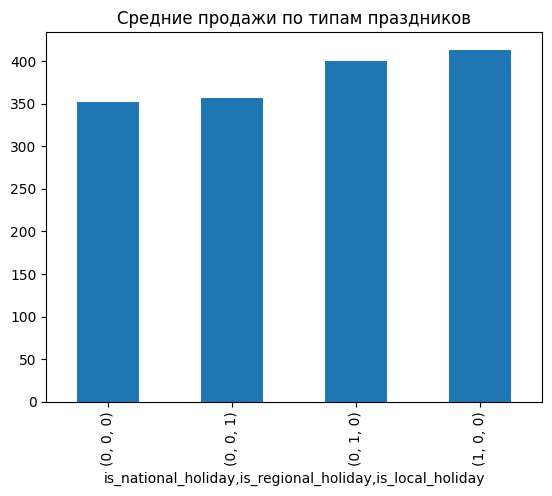

In [106]:
# Средние продажи по типам праздников
types = ['is_national_holiday', 'is_regional_holiday', 'is_local_holiday']
for col in types:
    print(f"{col}: {df[df[col]==1]['sales'].mean():.0f}")

df.groupby(['is_national_holiday', 'is_regional_holiday', 'is_local_holiday'])['sales'].mean().plot(kind='bar', title='Средние продажи по типам праздников')
plt.show()

In [107]:
# Средние продажи по каждому типу праздника
baseline = df[df['is_holiday'] == 0]['sales'].mean()  # обычный день

holiday_effect = {
    'Обычный день': baseline,
    'Любой праздник': df[df['is_holiday'] == 1]['sales'].mean(),
    'Национальный': df[df['is_national_holiday'] == 1]['sales'].mean(),
    'Региональный': df[df['is_regional_holiday'] == 1]['sales'].mean(),
    'Локальный': df[df['is_local_holiday'] == 1]['sales'].mean()
}

effect_df = pd.DataFrame.from_dict(holiday_effect, orient='index', columns=['Средние продажи'])
effect_df['Отклонение от обычного дня (%)'] = (
    (effect_df['Средние продажи'] - baseline) / baseline * 100
).round(1)

# Округляем продажи
effect_df['Средние продажи'] = effect_df['Средние продажи'].round(0).astype(int)

print(" Cross-tabulation: влияние праздников на продажи")
print(effect_df)

 Cross-tabulation: влияние праздников на продажи
                Средние продажи  Отклонение от обычного дня (%)
Обычный день                352                            0.00
Любой праздник              390                           10.70
Национальный                413                           17.30
Региональный                400                           13.40
Локальный                   357                            1.30


Вывод по анализу временных и календарных паттернов    

1. Преобразование праздничных признаков    

На основе структуры пропусков (85% NaN в holiday_type, locale и др.) сделан вывод: пропуски = отсутствие праздника.    
Созданы бинарные признаки:     
* is_holiday — есть ли праздник в этот день,   
* is_national_holiday, is_regional_holiday, is_local_holiday — тип праздника.   
Исходные праздничные колонки удалены.

2. Анализ временных паттернов (на основе агрегированных продаж)    
| Категория            | Наблюдение                                                          | Эффект                                          |
| -------------------- | ------------------------------------------------------------------- | ----------------------------------------------- |
| Общий тренд          | Устойчивый рост с 2013 по 2017 гг.                                  | Тренд нелинейный, ускорение в 2015–2016         |
| Недельная сезонность | Пик в выходные (Сб, Вс), минимум — в четверг                        | Выходные: около **+60%** к четвергу             |
| Месячная сезонность  | Пик — декабрь, спад — июль                                          | Декабрь: около **+30%** к средним месяцам       |
| День месяца          | Пик — 1-е число, постепенный рост к 31-му                           | Начало/конец месяца: **+15–20%** к середине     |
| Праздники            | Все праздники: **+11%**, Национальные: **+18%**, Локальные: **+2%** | `is_national_holiday` — наиболее сильный сигнал |


3. Cross-tabulation: Средние продажи по типам праздников   
| Категория      | Средние продажи | Отклонение от обычного дня (%) |
| -------------- | --------------- | ------------------------------ |
| Обычный день   | 352             | 0.00                           |
| Любой праздник | 390             | 10.70                          |
| Национальный   | 413             | 17.30                          |
| Региональный   | 400             | 13.40                          |
| Локальный      | 357             | 1.30                           |


4. Принятые решения    
Оставлены признаки:    
day_of_week, is_weekend, month, day, is_month_start, is_month_end,
is_holiday, is_national_holiday, is_regional_holiday.
is_local_holiday — можно удалить позже при отборе фичей (слабый эффект).

## Анализ временного охвата.

In [108]:
# Минимальная и максимальная дата по каждой паре
coverage = df.groupby(['store_nbr', 'family'])['date'].agg(['min', 'max']).reset_index()
print("Временной охват:")
print(coverage.sample(5))

Временной охват:
      store_nbr               family        min        max
1499         46             HARDWARE 2013-01-01 2017-08-15
610          19  HOME AND KITCHEN II 2013-01-01 2017-08-15
216           7            HOME CARE 2013-01-01 2017-08-15
352          11     LIQUOR,WINE,BEER 2013-01-01 2017-08-15
1586         49               BEAUTY 2013-01-01 2017-08-15


In [109]:
# Проверка: есть ли пары, где min > начала периода?
start_date = df['date'].min()
cold_start = coverage[coverage['min'] > start_date]
print(f"\nКоличество пар с 'холодным стартом': {len(cold_start)} из {len(coverage)}")



Количество пар с 'холодным стартом': 0 из 1782


In [110]:
df['date'] = pd.to_datetime(df['date'])

# Покрытие по месяцам и категориям
df['ym'] = df['date'].dt.to_period('M')  # Год-месяц

# проверяем: была ли запись в этот месяц по этой категории.
monthly_coverage = df.groupby(['family', 'ym']).size().unstack(fill_value=0)
monthly_coverage = (monthly_coverage > 0).astype(int)  # 1 = есть данные, 0 = нет
monthly_coverage

ym,2013-01,2013-02,2013-03,2013-04,2013-05,2013-06,2013-07,2013-08,2013-09,2013-10,2013-11,2013-12,2014-01,2014-02,2014-03,2014-04,2014-05,2014-06,2014-07,2014-08,2014-09,2014-10,2014-11,2014-12,2015-01,2015-02,2015-03,2015-04,2015-05,2015-06,2015-07,2015-08,2015-09,2015-10,2015-11,2015-12,2016-01,2016-02,2016-03,2016-04,2016-05,2016-06,2016-07,2016-08,2016-09,2016-10,2016-11,2016-12,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2017-07,2017-08
family,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
AUTOMOTIVE,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
BABY CARE,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
BEAUTY,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
BEVERAGES,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
BOOKS,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
BREAD/BAKERY,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
CELEBRATION,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
CLEANING,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
DAIRY,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


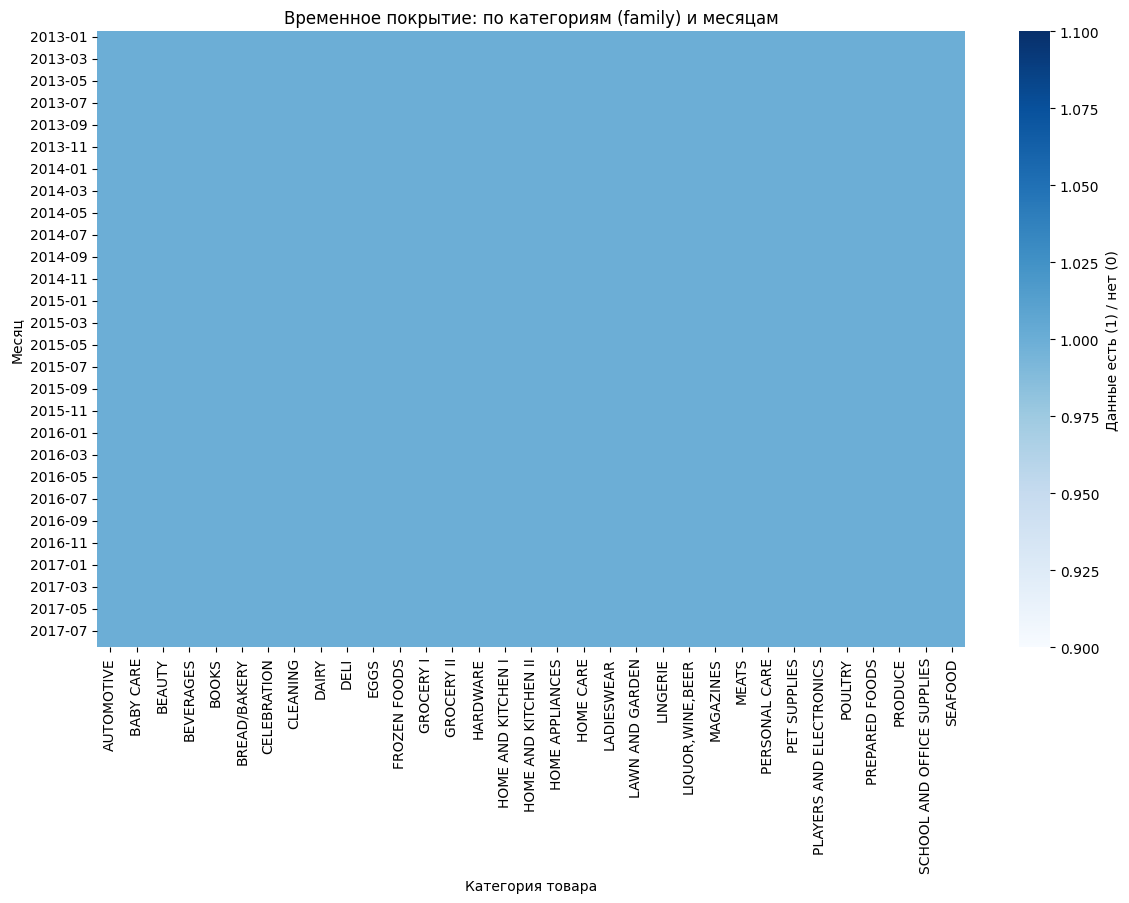

In [111]:
plt.figure(figsize=(14, 8))
sns.heatmap(monthly_coverage.T, cmap='Blues', cbar_kws={'label': 'Данные есть (1) / нет (0)'})
plt.title('Временное покрытие: по категориям (family) и месяцам')
plt.xlabel('Категория товара')
plt.ylabel('Месяц')
plt.show()

Все магазины и все категории товаров представлены в данных с самой первой даты наблюдений.
Нет новых магазинов, нет новых категорий — всё стабильно с самого начала.

### Анализ распределения продаж.

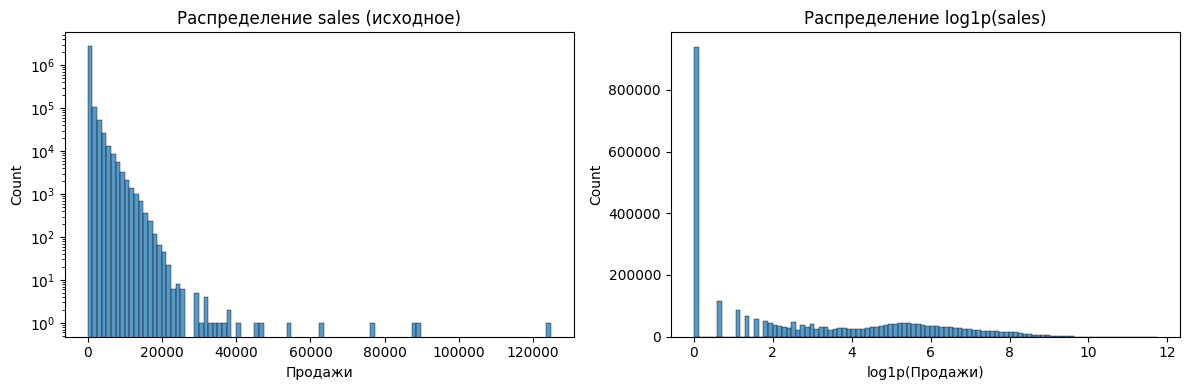

Топ-10 максимальных продаж:
              date  store_nbr     family     sales
2163723 2016-05-02          2  GROCERY I 124717.00
2445984 2016-10-07         39      MEATS  89576.36
2144154 2016-04-21         20  GROCERY I  87438.52
2139699 2016-04-18         45  GROCERY I  76090.00
2153031 2016-04-26          2  GROCERY I  63434.00
2145045 2016-04-21         45  GROCERY I  53874.00
562596  2013-11-12         44  GROCERY I  46271.00
1257246 2014-12-08         35  GROCERY I  45361.00
1916586 2015-12-14         35  GROCERY I  40351.46
2760297 2017-04-02          9  GROCERY I  38422.62


In [112]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['sales'], bins=100, kde=False)
plt.title('Распределение sales (исходное)')
plt.xlabel('Продажи')
plt.yscale('log')

# Гистограмма log1p(sales)
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['sales']), bins=100, kde=False)
plt.title('Распределение log1p(sales)')
plt.xlabel('log1p(Продажи)')

plt.tight_layout()
plt.show()

# Топ-10 максимальных продаж
print("Топ-10 максимальных продаж:")
print(df.nlargest(10, 'sales')[['date', 'store_nbr', 'family', 'sales']])

Распределение продаж характеризуется сильной положительной асимметрией: подавляющее большинство значений сосредоточено в диапазоне от 0 до 20 000, а после логарифмирования — вблизи нуля. Топ-10 наблюдений не связан с праздниками (проверено по месячной разбивке) и представляет один и тот же продукт в разных магазинах. Анализ временных рядов после учёта «холодного старта» показал отсутствие периодов с нулевыми продажами — данные полные, «дыр» из-за отсутствия товара нет.

Топ-10 категорий с наибольшей долей нулей:
                        family  zero_ratio
4                        BOOKS        0.97
1                    BABY CARE        0.94
31  SCHOOL AND OFFICE SUPPLIES        0.74
17             HOME APPLIANCES        0.74
19                  LADIESWEAR        0.60
23                   MAGAZINES        0.57
26                PET SUPPLIES        0.55
14                    HARDWARE        0.48
20             LAWN AND GARDEN        0.47
27     PLAYERS AND ELECTRONICS        0.45


<Figure size 1000x600 with 0 Axes>

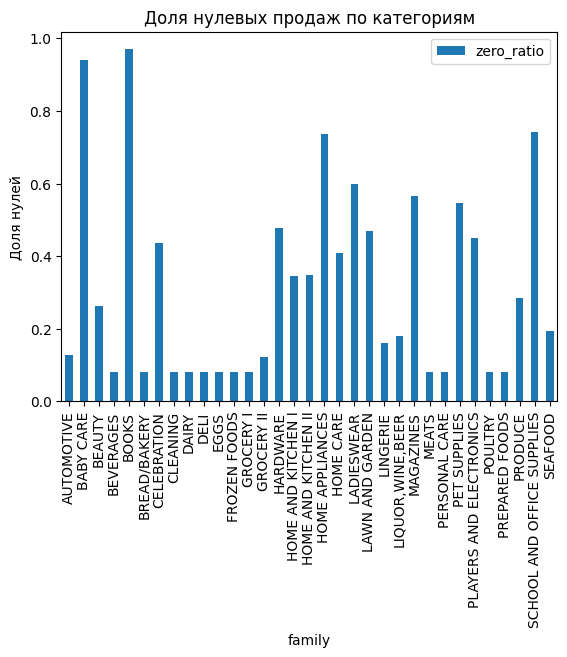

In [113]:
# Доля нулей по каждой категории
zero_ratio = df.groupby('family')['sales'].apply(lambda x: (x == 0).mean()).reset_index()
zero_ratio.columns = ['family', 'zero_ratio']

# Топ-10 категорий с самой высокой долей нулей
print("Топ-10 категорий с наибольшей долей нулей:")
print(zero_ratio.sort_values('zero_ratio', ascending=False).head(10))

# Визуализация
plt.figure(figsize=(10, 6))
zero_ratio.plot(x='family', y='zero_ratio', kind='bar', title='Доля нулевых продаж по категориям')
plt.ylabel('Доля нулей')
plt.xticks(rotation=90)
plt.show()

Анализ доли нулевых продаж по категориям выявил наличие прерывистого спроса (intermittent demand) в ряде товарных групп.    Такие категории, как BOOKS (97% нулей), BABY CARE (94%), SCHOOL AND OFFICE SUPPLIES (74%) и HOME APPLIANCES (74%), характеризуются крайне редкими продажами — это типично для нишевых, сезонных или низкочастотных товаров в ритейле.

Вывод: отсутствие продаж по этим позициям — не ошибка данных, а бизнес-реальность. Такие ряды не подходят для традиционных моделей (например, градиентного бустинга по исходным продажам без учёта спарсности).

Рекомендации:

Не удалять и не импутировать нули — они несут информативную нагрузку.
Рассмотреть двухступенчатый подход:    
* Модель 1: предсказывает вероятность продажи (бинарная классификация: 0 vs >0).
* Модель 2: предсказывает объём продаж при условии продажи (регрессия только по ненулевым).   
* Либо использовать модели, устойчивые к прерывистому спросу (например, Croston’s method для агрегированных рядов или квантильные модели с фокусом на нули).

# ABC анализ

## ABC-анализ по family
Цель: выделить категории, дающие основной вклад в выручку.

In [114]:
# 1. Агрегация и сортировка
family_sales = df.groupby('family')['sales'].sum().sort_values(ascending=False).reset_index()
family_sales

,family,sales
0,GROCERY I,343462734.89
1,BEVERAGES,216954486.00
2,PRODUCE,122704684.68
3,CLEANING,97521289.00
4,DAIRY,64487709.00
5,BREAD/BAKERY,42133945.58
6,POULTRY,31876004.47
7,MEATS,31086468.40
8,PERSONAL CARE,24592051.00
9,DELI,24110322.47


In [115]:
family_sales['cumsum_sales'] = family_sales['sales'].cumsum()
family_sales['cumsum_sales'].head()

,cumsum_sales
0,343462734.89
1,560417220.89
2,683121905.56
3,780643194.56
4,845130903.56


In [116]:
total_sales = family_sales['sales'].sum()
family_sales['cumsum_ratio'] = family_sales['cumsum_sales'] / total_sales
family_sales['family_share'] = family_sales['sales'] / total_sales
family_sales['family_rank'] = range(1, len(family_sales) + 1)
family_sales

,family,sales,cumsum_sales,cumsum_ratio,family_share,family_rank
0,GROCERY I,343462734.89,343462734.89,0.32,0.32,1
1,BEVERAGES,216954486.00,560417220.89,0.52,0.20,2
2,PRODUCE,122704684.68,683121905.56,0.64,0.11,3
3,CLEANING,97521289.00,780643194.56,0.73,0.09,4
4,DAIRY,64487709.00,845130903.56,0.79,0.06,5
5,BREAD/BAKERY,42133945.58,887264849.14,0.83,0.04,6
6,POULTRY,31876004.47,919140853.61,0.86,0.03,7
7,MEATS,31086468.40,950227322.01,0.89,0.03,8
8,PERSONAL CARE,24592051.00,974819373.01,0.91,0.02,9
9,DELI,24110322.47,998929695.48,0.93,0.02,10



=== Топ-10 категорий по продажам ===
GROCERY I                      :  343,462,735 (32.0%)
BEVERAGES                      :  216,954,486 (20.2%)
PRODUCE                        :  122,704,685 (11.4%)
CLEANING                       :   97,521,289 (9.1%)
DAIRY                          :   64,487,709 (6.0%)
BREAD/BAKERY                   :   42,133,946 (3.9%)
POULTRY                        :   31,876,004 (3.0%)
MEATS                          :   31,086,468 (2.9%)
PERSONAL CARE                  :   24,592,051 (2.3%)
DELI                           :   24,110,322 (2.2%)

=== Класс A (до 80% кумулятивных продаж): 5 категорий ===
   family        sales  cumsum_ratio
GROCERY I 343462734.89          0.32
BEVERAGES 216954486.00          0.52
  PRODUCE 122704684.68          0.64
 CLEANING  97521289.00          0.73
    DAIRY  64487709.00          0.79


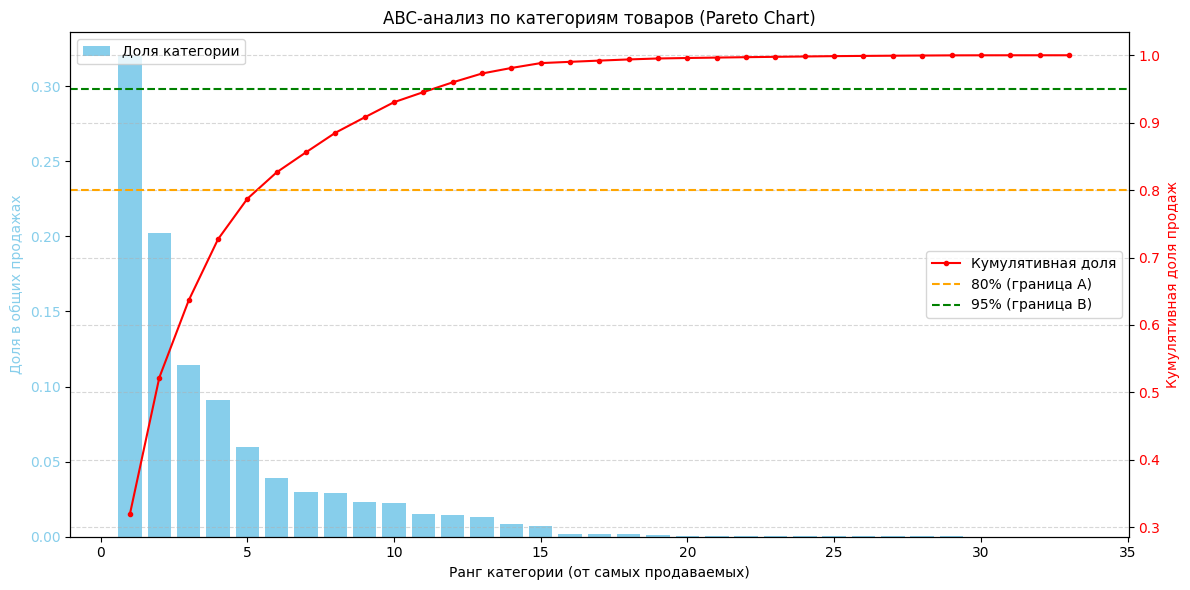

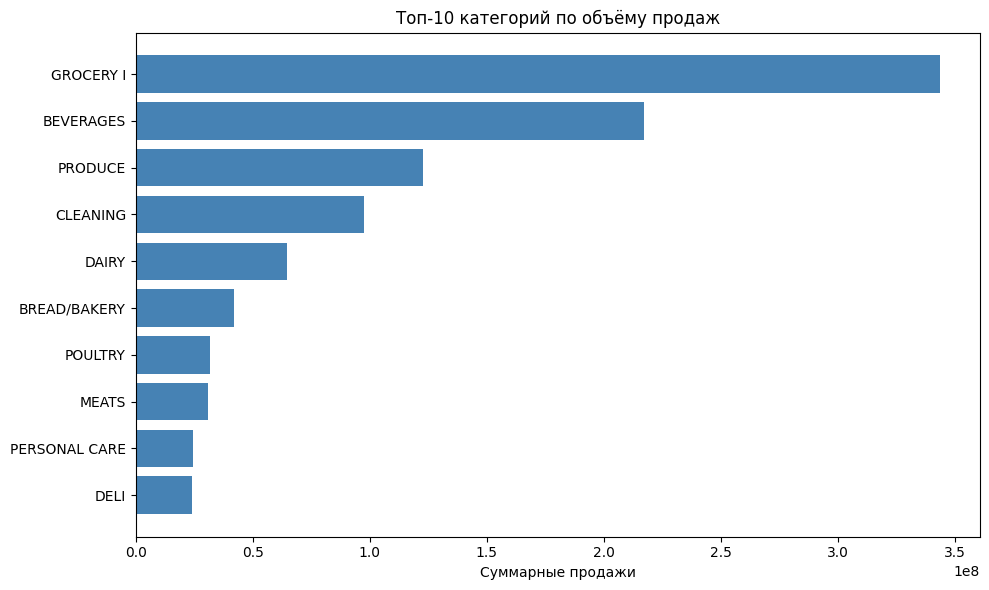

In [117]:
# 2. Присвоение ABC-классов
def assign_abc(ratio):
    if ratio <= 0.80:
        return 'A'
    elif ratio <= 0.95:
        return 'B'
    else:
        return 'C'

family_sales['family_importance'] = family_sales['cumsum_ratio'].apply(assign_abc)

# 3. Вывод топа и состава класса A
top10_families = family_sales.head(10)
class_A = family_sales[family_sales['family_importance'] == 'A']

print("\n=== Топ-10 категорий по продажам ===")
for i, row in top10_families.iterrows():
    print(f"{row['family']:<30} : {row['sales']:>12,.0f} ({row['family_share']*100:.1f}%)")

print(f"\n=== Класс A (до 80% кумулятивных продаж): {len(class_A)} категорий ===")
print(class_A[['family', 'sales', 'cumsum_ratio']].to_string(index=False))

# 4. Визуализация — Pareto Chart
plt.figure(figsize=(12, 6))
ax1 = plt.gca()
ax1.bar(family_sales['family_rank'], family_sales['family_share'], color='skyblue', label='Доля категории')
ax1.set_xlabel('Ранг категории (от самых продаваемых)')
ax1.set_ylabel('Доля в общих продажах', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')

ax2 = ax1.twinx()
ax2.plot(family_sales['family_rank'], family_sales['cumsum_ratio'], color='red', marker='o', markersize=3, label='Кумулятивная доля')
ax2.axhline(0.80, color='orange', linestyle='--', label='80% (граница A)')
ax2.axhline(0.95, color='green', linestyle='--', label='95% (граница B)')
ax2.set_ylabel('Кумулятивная доля продаж', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('ABC-анализ по категориям товаров (Pareto Chart)')
ax1.legend(loc='upper left')
ax2.legend(loc='center right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 5. Визуализация — Топ-10 категорий
plt.figure(figsize=(10, 6))
plt.barh(top10_families['family'][::-1], top10_families['sales'][::-1], color='steelblue')
plt.xlabel('Суммарные продажи')
plt.title('Топ-10 категорий по объёму продаж')
plt.tight_layout()
plt.show()

# 6. Мёрдж обратно в основной датафрейм
df = df.merge(family_sales[['family', 'family_importance']], on='family', how='left')

## ABC-анализ по магазинам (store_nbr)
Цель: выделить магазины, дающие основной вклад в выручку.


=== Топ-10 магазинов по продажам ===
Магазин 44 :   62,087,553 (5.8%)
Магазин 45 :   54,498,010 (5.1%)
Магазин 47 :   50,948,310 (4.7%)
Магазин 3  :   50,481,910 (4.7%)
Магазин 49 :   43,420,096 (4.0%)
Магазин 46 :   41,896,062 (3.9%)
Магазин 48 :   35,933,130 (3.3%)
Магазин 51 :   32,911,490 (3.1%)
Магазин 8  :   30,494,287 (2.8%)
Магазин 50 :   28,653,021 (2.7%)

=== Класс A (до 80% кумулятивных продаж): 31 магазинов ===
 store_nbr       sales  cumsum_ratio
        44 62087553.25          0.06
        45 54498010.42          0.11
        47 50948310.06          0.16
         3 50481910.19          0.20
        49 43420095.78          0.24
        46 41896062.12          0.28
        48 35933130.27          0.32
        51 32911489.54          0.35
         8 30494286.93          0.38
        50 28653020.62          0.40
        11 28325558.48          0.43
         7 26952049.58          0.45
         9 26409441.06          0.48
         6 25183680.00          0.50
        24 237677

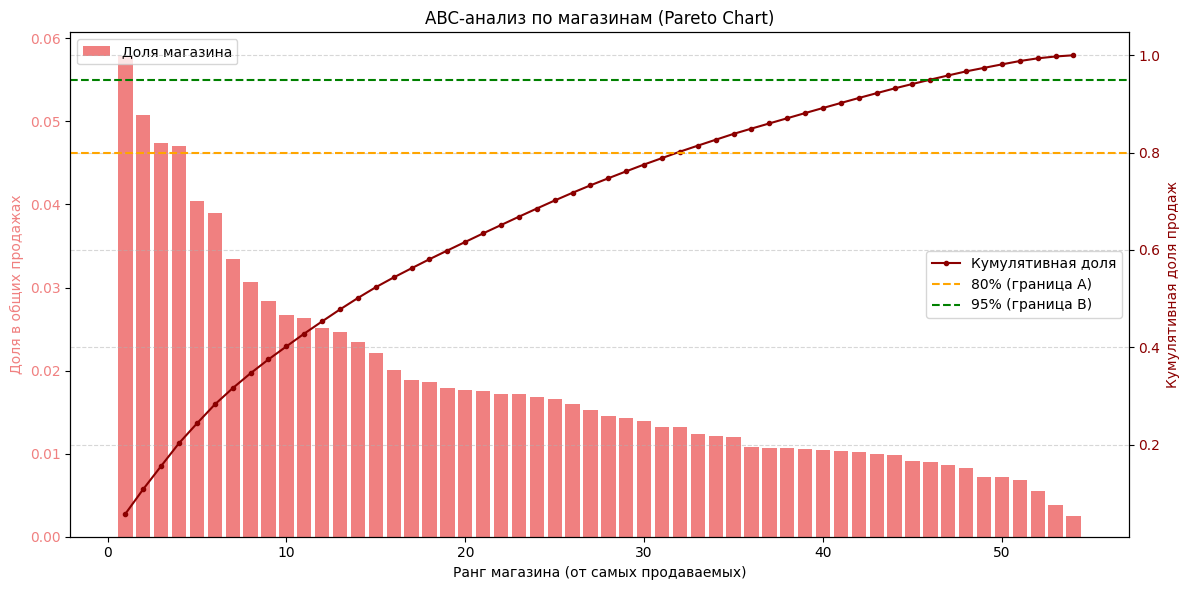

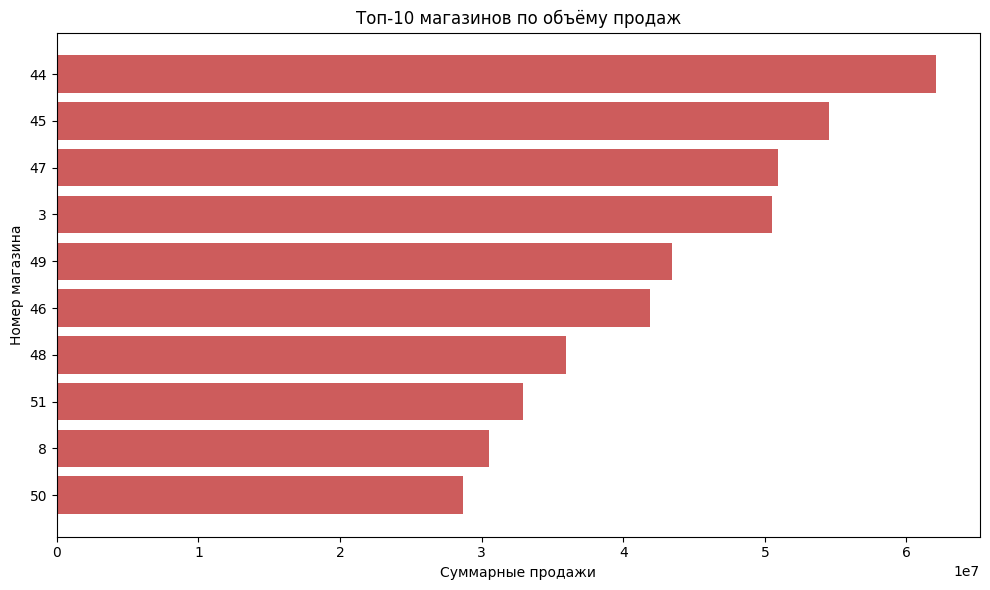

In [118]:
# 1. Агрегация и сортировка по store_nbr
store_sales = df.groupby('store_nbr')['sales'].sum().sort_values(ascending=False).reset_index()
store_sales['cumsum_sales'] = store_sales['sales'].cumsum()
total_sales = store_sales['sales'].sum()
store_sales['cumsum_ratio'] = store_sales['cumsum_sales'] / total_sales
store_sales['store_share'] = store_sales['sales'] / total_sales
store_sales['store_rank'] = range(1, len(store_sales) + 1)

# 2. Присвоение ABC-классов
def assign_abc(ratio):
    if ratio <= 0.80:
        return 'A'
    elif ratio <= 0.95:
        return 'B'
    else:
        return 'C'

store_sales['store_importance'] = store_sales['cumsum_ratio'].apply(assign_abc)

# 3. Вывод информации
top10_stores = store_sales.head(10)
class_A_stores = store_sales[store_sales['store_importance'] == 'A']

print("\n=== Топ-10 магазинов по продажам ===")
for i, row in top10_stores.iterrows():
    print(f"Магазин {row['store_nbr']:<2} : {row['sales']:>12,.0f} ({row['store_share']*100:.1f}%)")

print(f"\n=== Класс A (до 80% кумулятивных продаж): {len(class_A_stores)} магазинов ===")
print(class_A_stores[['store_nbr', 'sales', 'cumsum_ratio']].to_string(index=False))

# 4. Визуализация — Pareto Chart для магазинов
plt.figure(figsize=(12, 6))
ax1 = plt.gca()
ax1.bar(store_sales['store_rank'], store_sales['store_share'], color='lightcoral', label='Доля магазина')
ax1.set_xlabel('Ранг магазина (от самых продаваемых)')
ax1.set_ylabel('Доля в общих продажах', color='lightcoral')
ax1.tick_params(axis='y', labelcolor='lightcoral')

ax2 = ax1.twinx()
ax2.plot(store_sales['store_rank'], store_sales['cumsum_ratio'], color='darkred', marker='o', markersize=3, label='Кумулятивная доля')
ax2.axhline(0.80, color='orange', linestyle='--', label='80% (граница A)')
ax2.axhline(0.95, color='green', linestyle='--', label='95% (граница B)')
ax2.set_ylabel('Кумулятивная доля продаж', color='darkred')
ax2.tick_params(axis='y', labelcolor='darkred')

plt.title('ABC-анализ по магазинам (Pareto Chart)')
ax1.legend(loc='upper left')
ax2.legend(loc='center right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 5. Визуализация — Топ-10 магазинов
plt.figure(figsize=(10, 6))
plt.barh(top10_stores['store_nbr'][::-1].astype(str), top10_stores['sales'][::-1], color='indianred')
plt.xlabel('Суммарные продажи')
plt.title('Топ-10 магазинов по объёму продаж')
plt.ylabel('Номер магазина')
plt.tight_layout()
plt.show()

# 6. Мёрдж обратно в основной датафрейм
df = df.merge(store_sales[['store_nbr', 'store_importance']], on='store_nbr', how='left')

In [119]:
df[['family_importance','store_importance']].sample(10)

,family_importance,store_importance
1368055,A,A
850568,C,A
2448075,A,A
1582984,A,B
1602856,C,C
2541505,C,A
573780,B,A
35018,B,A
2521156,C,A
872146,C,A


###  ABC-анализ по категориям товаров и магазинам

 Цель анализа   
Выявить ключевые категории товаров и магазины, формирующие основную долю продаж, чтобы оптимизировать усилия по прогнозированию: сконцентрироваться на важном (A), упростить для второстепенного (B/C).

---

 Результаты по категориям (`family`)

- **Топ-5 категорий (класс A)** — **79% всех продаж**:
  - `GROCERY I` (32%), `BEVERAGES` (20%), `PRODUCE` (11%), `CLEANING` (9%), `DAIRY` (6%).
- **Вывод**:
  > Эти категории — **ядра бизнеса**. Их прогнозирование должно быть **максимально точным**. Вероятно, они имеют **стабильный спрос**, поддающийся стандартным моделям (LightGBM, Prophet).  
  > Остальные категории (B и C) — **низкочастотные или нишевые** (например, `BOOKS`, `BABY CARE`). Для них требуется **специальный подход** (двухступенчатая модель или Croston).

---

 Результаты по магазинам (`store_nbr`)

- **Топ-31 магазинов (класс A)** — **80% всех продаж**.
- **Топ-10 магазинов** — **~40% продаж**, без явного доминирования одного магазина.
- **Вывод**:
  > Продажи распределены **по нескольким лидерам**, что снижает риск от потери одного объекта.  
  > Магазины класса A — вероятно, **флагманские точки в крупных городах**. Их стоит анализировать отдельно, возможно, с учётом типа магазина и локации.  
  > Магазины класса C (23 шт.) — **региональные или маленькие**. Для них можно использовать **агрегированные прогнозы** (по типу магазина или кластеру), чтобы сэкономить ресурсы.

---

 Стратегические рекомендации

1. **Для моделирования**:
   - Сфокусироваться на **A-категориях и A-магазинах** — они дают 80% продаж.
   - Для C-категорий — использовать **двухступенчатую модель** (0 vs >0 + объём).
   - Для C-магазинов — применять **агрегированные прогнозы** или простые методы (скользящее среднее).

2. **Для дальнейшего анализа**:
   - Проверить связь `store_type` и `store_importance`.
   - Исследовать, как `onpromotion` влияет на A-категории по сравнению с C.
   - Кластеризовать временные ряды внутри A-категорий — возможно, есть разные паттерны (сезонные, стабильные).

---

## Кластеризация   
Цель:   Найти группы временных рядов, которые похожи по форме поведения (сезонные, стабильные, всплесковые), чтобы применять к ним разные стратегии моделирования.

In [120]:
# 1. Работаем ТОЛЬКО с A-категориями (самые важные 79% продаж)
df_A = df[df['family_importance'] == 'A'].copy()
df_A.sample(5)

# 2. Агрегация до недельного уровня
df_A['year_week'] = df_A['date'].dt.to_period('W')
weekly_sales = df_A.groupby(['store_nbr', 'family', 'year_week'])['sales'].sum().reset_index()
weekly_sales[:5]

,store_nbr,family,year_week,sales
0,1,BEVERAGES,2012-12-31/2013-01-06,4530.00
1,1,BEVERAGES,2013-01-07/2013-01-13,6968.00
2,1,BEVERAGES,2013-01-14/2013-01-20,7131.00
3,1,BEVERAGES,2013-01-21/2013-01-27,6524.00
4,1,BEVERAGES,2013-01-28/2013-02-03,6012.00


In [121]:
# 3. Пивот: строки = (store_nbr, family), столбцы = недели
weekly_pivot = weekly_sales.pivot_table(
    index=['store_nbr', 'family'],
    columns='year_week',
    values='sales',
    fill_value=0
)
weekly_pivot[:5]

year_week            2012-12-31/2013-01-06  2013-01-07/2013-01-13  2013-01-14/2013-01-20  2013-01-21/2013-01-27  2013-01-28/2013-02-03  2013-02-04/2013-02-10  2013-02-11/2013-02-17  2013-02-18/2013-02-24  2013-02-25/2013-03-03  2013-03-04/2013-03-10  2013-03-11/2013-03-17  2013-03-18/2013-03-24  2013-03-25/2013-03-31  2013-04-01/2013-04-07  2013-04-08/2013-04-14  2013-04-15/2013-04-21  2013-04-22/2013-04-28  2013-04-29/2013-05-05  2013-05-06/2013-05-12  2013-05-13/2013-05-19  2013-05-20/2013-05-26  2013-05-27/2013-06-02  2013-06-03/2013-06-09  2013-06-10/2013-06-16  2013-06-17/2013-06-23  2013-06-24/2013-06-30  2013-07-01/2013-07-07  2013-07-08/2013-07-14  2013-07-15/2013-07-21  2013-07-22/2013-07-28  2013-07-29/2013-08-04  2013-08-05/2013-08-11  2013-08-12/2013-08-18  2013-08-19/2013-08-25  2013-08-26/2013-09-01  2013-09-02/2013-09-08  2013-09-09/2013-09-15  2013-09-16/2013-09-22  2013-09-23/2013-09-29  2013-09-30/2013-10-06  2013-10-07/2013-10-13  2013-10-14/2013-10-20  2013-10-21/2013-10-27  2013-10-28/2013-11-03  2013-11-04/2013-11-10  2013-11-11/2013-11-17  2013-11-18/2013-11-24  2013-11-25/2013-12-01  2013-12-02/2013-12-08  2013-12-09/2013-12-15  2013-12-16/2013-12-22  2013-12-23/2013-12-29  2013-12-30/2014-01-05  2014-01-06/2014-01-12  2014-01-13/2014-01-19  2014-01-20/2014-01-26  2014-01-27/2014-02-02  2014-02-03/2014-02-09  2014-02-10/2014-02-16  2014-02-17/2014-02-23  2014-02-24/2014-03-02  2014-03-03/2014-03-09  2014-03-10/2014-03-16  2014-03-17/2014-03-23  2014-03-24/2014-03-30  2014-03-31/2014-04-06  2014-04-07/2014-04-13  2014-04-14/2014-04-20  2014-04-21/2014-04-27  2014-04-28/2014-05-04  2014-05-05/2014-05-11  2014-05-12/2014-05-18  2014-05-19/2014-05-25  2014-05-26/2014-06-01  2014-06-02/2014-06-08  2014-06-09/2014-06-15  2014-06-16/2014-06-22  2014-06-23/2014-06-29  2014-06-30/2014-07-06  2014-07-07/2014-07-13  2014-07-14/2014-07-20  2014-07-21/2014-07-27  2014-07-28/2014-08-03  2014-08-04/2014-08-10  2014-08-11/2014-08-17  2014-08-18/2014-08-24  2014-08-25/2014-08-31  2014-09-01/2014-09-07  2014-09-08/2014-09-14  2014-09-15/2014-09-21  2014-09-22/2014-09-28  2014-09-29/2014-10-05  2014-10-06/2014-10-12  2014-10-13/2014-10-19  2014-10-20/2014-10-26  2014-10-27/2014-11-02  2014-11-03/2014-11-09  2014-11-10/2014-11-16  2014-11-17/2014-11-23  2014-11-24/2014-11-30  2014-12-01/2014-12-07  2014-12-08/2014-12-14  2014-12-15/2014-12-21  2014-12-22/2014-12-28  2014-12-29/2015-01-04  2015-01-05/2015-01-11  2015-01-12/2015-01-18  2015-01-19/2015-01-25  2015-01-26/2015-02-01  2015-02-02/2015-02-08  2015-02-09/2015-02-15  2015-02-16/2015-02-22  2015-02-23/2015-03-01  2015-03-02/2015-03-08  2015-03-09/2015-03-15  2015-03-16/2015-03-22  2015-03-23/2015-03-29  2015-03-30/2015-04-05  2015-04-06/2015-04-12  2015-04-13/2015-04-19  2015-04-20/2015-04-26  2015-04-27/2015-05-03  2015-05-04/2015-05-10  2015-05-11/2015-05-17  2015-05-18/2015-05-24  2015-05-25/2015-05-31  2015-06-01/2015-06-07  2015-06-08/2015-06-14  2015-06-15/2015-06-21  2015-06-22/2015-06-28  2015-06-29/2015-07-05  2015-07-06/2015-07-12  2015-07-13/2015-07-19  2015-07-20/2015-07-26  2015-07-27/2015-08-02  2015-08-03/2015-08-09  2015-08-10/2015-08-16  2015-08-17/2015-08-23  2015-08-24/2015-08-30  2015-08-31/2015-09-06  2015-09-07/2015-09-13  2015-09-14/2015-09-20  2015-09-21/2015-09-27  2015-09-28/2015-10-04  2015-10-05/2015-10-11  2015-10-12/2015-10-18  2015-10-19/2015-10-25  2015-10-26/2015-11-01  2015-11-02/2015-11-08  2015-11-09/2015-11-15  2015-11-16/2015-11-22  2015-11-23/2015-11-29  2015-11-30/2015-12-06  2015-12-07/2015-12-13  2015-12-14/2015-12-20  2015-12-21/2015-12-27  2015-12-28/2016-01-03  2016-01-04/2016-01-10  2016-01-11/2016-01-17  2016-01-18/2016-01-24  2016-01-25/2016-01-31  2016-02-01/2016-02-07  2016-02-08/2016-02-14  2016-02-15/2016-02-21  2016-02-22/2016-02-28  2016-02-29/2016-03-06  2016-03-07/2016-03-13  2016-03-14/2016-03-20  2016-03-21/2016-03-27  2016-03-28/2016-04-03  2016-04-04/2016-04-10  2016-04-11/2016-04-17  2016-04-18/2016-04-24  

In [122]:
# 4. Нормализация КАЖДОГО ряда по отдельности (по строке!)
scaler = MinMaxScaler()
normalized_matrix = scaler.fit_transform(weekly_pivot)  # shape: (N, T)

# 5. Кластеризация
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(normalized_matrix)

# 6. СОЗДАЁМ cluster_df
cluster_df = pd.DataFrame({
    'store_nbr': weekly_pivot.index.get_level_values(0),
    'family': weekly_pivot.index.get_level_values(1),
    'sales_pattern_cluster': cluster_labels
})
cluster_df.head()

,store_nbr,family,sales_pattern_cluster
0,1,BEVERAGES,0
1,1,CLEANING,0
2,1,DAIRY,0
3,1,GROCERY I,3
4,1,PRODUCE,0


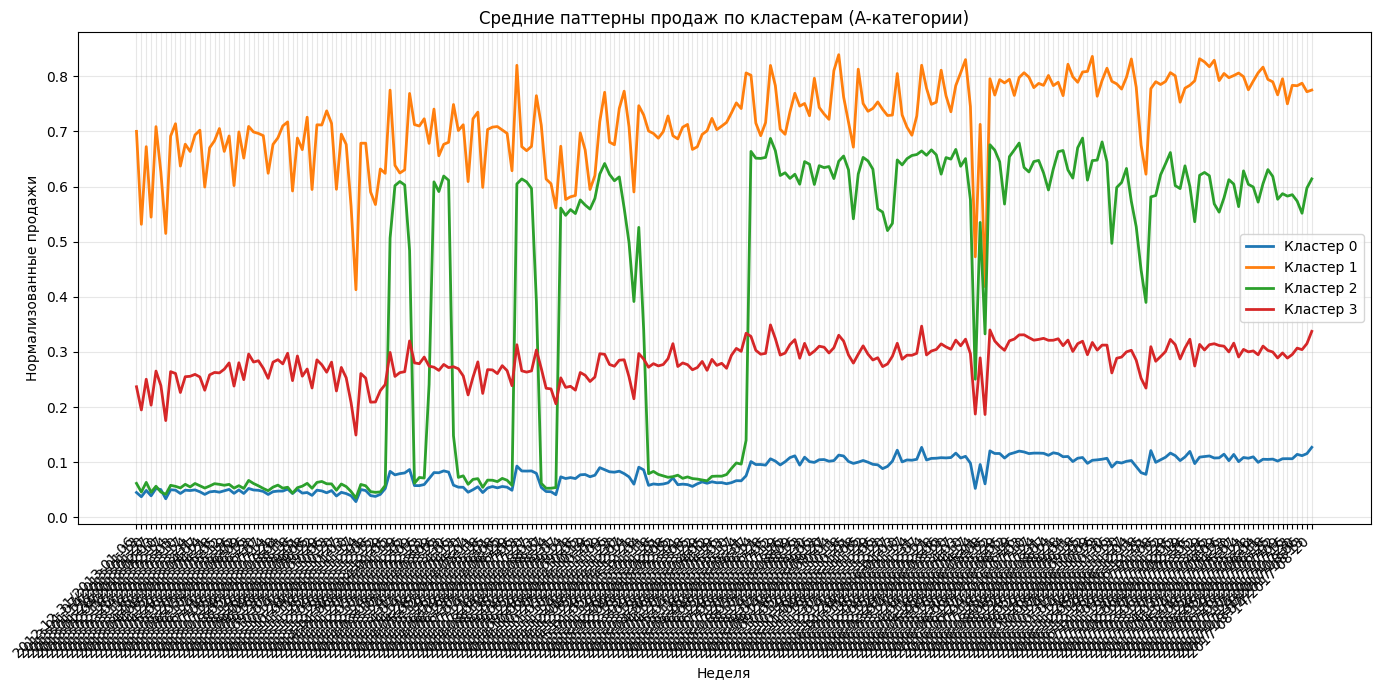


=== Распределение по кластерам ===
sales_pattern_cluster
0    181
1     14
2     10
3     65
Name: count, dtype: int64

=== Пример: первые 5 записей из кластера 0 ===
   store_nbr     family  sales_pattern_cluster
0          1  BEVERAGES                      0
1          1   CLEANING                      0
2          1      DAIRY                      0
4          1    PRODUCE                      0
6          2   CLEANING                      0


In [123]:
# Убираем дубликаты
cluster_df = cluster_df.drop_duplicates(subset=['store_nbr', 'family']).reset_index(drop=True)

# 7. Визуализация центроидов
plt.figure(figsize=(14, 7))
weeks = [str(w) for w in weekly_pivot.columns]
for i in range(n_clusters):
    plt.plot(weeks, kmeans.cluster_centers_[i], label=f'Кластер {i}', linewidth=2)
plt.title('Средние паттерны продаж по кластерам (A-категории)')
plt.xlabel('Неделя')
plt.ylabel('Нормализованные продажи')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Статистика по кластерам
print("\n=== Распределение по кластерам ===")
print(cluster_df['sales_pattern_cluster'].value_counts().sort_index())

# 9. Пример: посмотреть, что в кластере 0
print("\n=== Пример: первые 5 записей из кластера 0 ===")
print(cluster_df[cluster_df['sales_pattern_cluster'] == 0].head())

# 10. Мёрджим в основной датафрейм
df = df.merge(cluster_df, on=['store_nbr', 'family'], how='left')

# Для не-A категорий проставим -1 (чтобы отличать)
df['sales_pattern_cluster'] = df['sales_pattern_cluster'].fillna(-1).astype(int)

## Кластерный анализ

### 1. Распределение категорий по кластерам


=== Распределение категорий по кластерам ===
family                 BEVERAGES  CLEANING  DAIRY  GROCERY I  PRODUCE
sales_pattern_cluster                                                
0                             28        47     50         11       45
1                              4         0      0         10        0
2                              2         0      0          0        8
3                             20         7      4         33        1


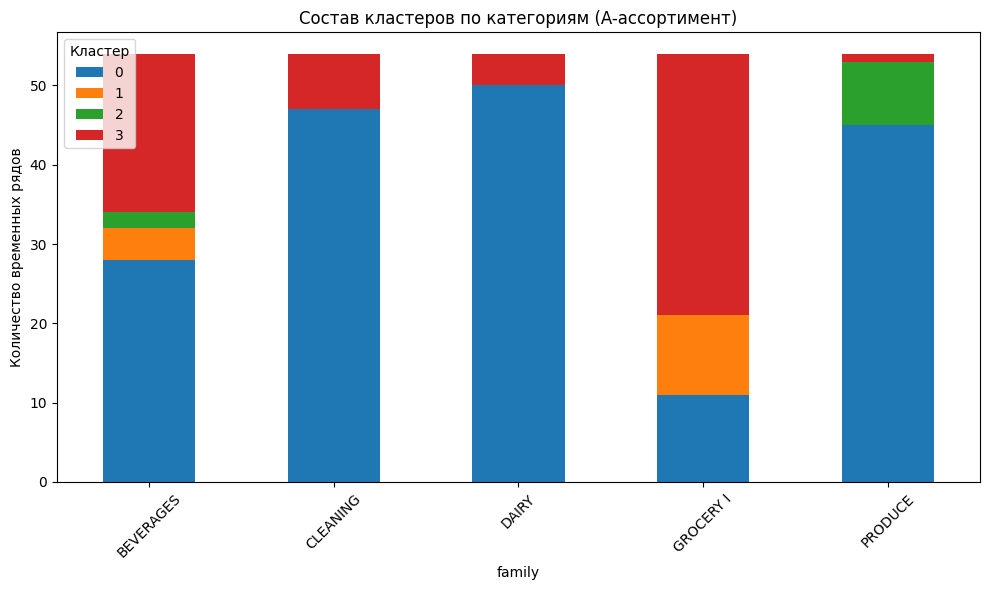

In [124]:
# Сколько раз каждая категория встречается в кластере
family_by_cluster = cluster_df.groupby(['sales_pattern_cluster', 'family']).size().unstack(fill_value=0)
print("\n=== Распределение категорий по кластерам ===")
print(family_by_cluster)

family_by_cluster.T.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Состав кластеров по категориям (A-ассортимент)')
plt.ylabel('Количество временных рядов')
plt.xticks(rotation=45)
plt.legend(title='Кластер')
plt.tight_layout()
plt.show()

### 2. Распределение магазинов по кластерам

In [125]:
# Топ-3 магазинов в каждом кластере
print("\n=== Топ-3 магазина в каждом кластере ===")
for cluster_id in sorted(cluster_df['sales_pattern_cluster'].unique()):
    if cluster_id == -1:
        continue
    top_stores = cluster_df[cluster_df['sales_pattern_cluster'] == cluster_id]['store_nbr'].value_counts().head(3)
    print(f"Кластер {cluster_id}: {top_stores.to_dict()}")


=== Топ-3 магазина в каждом кластере ===
Кластер 0: {22: 5, 21: 5, 29: 5}
Кластер 1: {3: 2, 44: 2, 47: 2}
Кластер 2: {49: 2, 3: 1, 7: 1}
Кластер 3: {24: 3, 2: 2, 8: 2}


### 3. Медианные продажи по кластерам

In [126]:
# Добавим в cluster_df медианные продажи для каждого ряда (из исходного df)
median_sales_per_series = df.groupby(['store_nbr', 'family'])['sales'].median().reset_index()
median_sales_per_series.rename(columns={'sales': 'median_sales'}, inplace=True)

# Мёрджим
cluster_df_with_median = cluster_df.merge(median_sales_per_series, on=['store_nbr', 'family'])

# Группируем по кластеру
cluster_medians = cluster_df_with_median.groupby('sales_pattern_cluster')['median_sales'].agg(['mean', 'median', 'count'])
print("\n=== Медианные продажи по кластерам ===")
print(cluster_medians)


=== Медианные продажи по кластерам ===
                         mean  median  count
sales_pattern_cluster                       
0                      817.21  826.00    181
1                     6960.29 6501.50     14
2                     5182.45 4708.17     10
3                     2843.35 2671.50     65


### Распределение кластеров

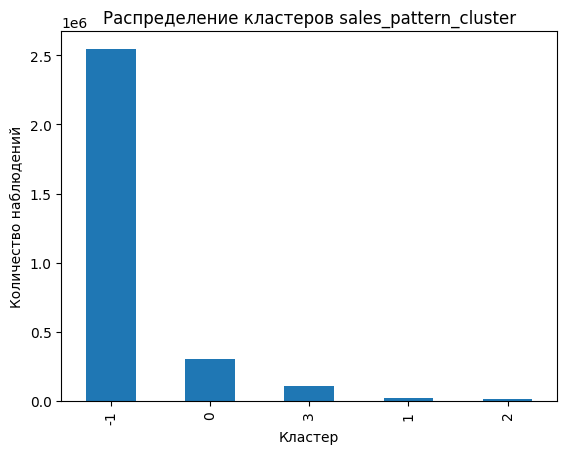

In [127]:
cluster_counts = df['sales_pattern_cluster'].value_counts()
cluster_counts.plot(kind='bar')
plt.title('Распределение кластеров sales_pattern_cluster')
plt.xlabel('Кластер')
plt.ylabel('Количество наблюдений')
plt.show()


<Axes: xlabel='day_of_week'>

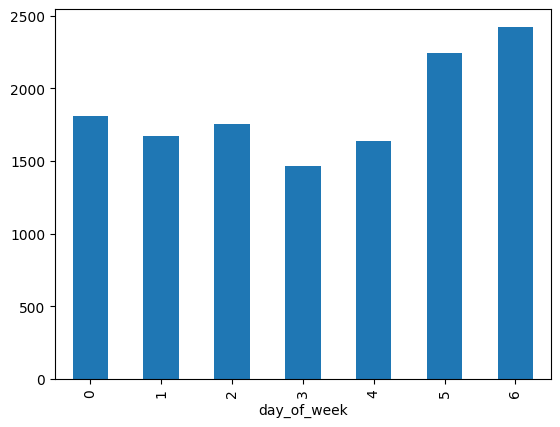

In [128]:
# Средние продажи по дням недели для A-категорий
df[df['family_importance']=='A'].groupby('day_of_week')['sales'].mean().plot(kind='bar')

In [129]:
# Сводка по топ-магазинам
top_store_nos = [44, 45, 47, 3, 49, 46, 48, 51, 8, 50]
df[df['store_nbr'].isin(top_store_nos)][['store_nbr', 'city', 'store_type']].drop_duplicates()

,store_nbr,city,store_type
726,3,Quito,D
1254,44,Quito,A
1287,45,Quito,A
1320,46,Quito,A
1353,47,Quito,A
1386,48,Quito,A
1419,49,Quito,A
1485,50,Ambato,A
1518,51,Guayaquil,A
1716,8,Quito,D


In [130]:
# Топ-категории чаще участвуют в промоакциях (onpromotion)
promo_share = df.groupby('family_importance')['onpromotion'].mean()
print(promo_share)

family_importance
A   11.72
B    3.46
C    0.30
Name: onpromotion, dtype: float64


##

| Кластер | Кол-во рядов | Основные категории | Медиана продаж | Топ-магазины | Интерпретация |
|--------:|-------------:|--------------------|---------------:|--------------|---------------|
| 0 | 181 | DAIRY, CLEANING, PRODUCE | 826 | 22, 21, 29 | Низкий объём, стабильный спрос (повседневные товары в небольших магазинах) |
| 1 | 14 | GROCERY I (10), BEVERAGES (4) | 6501 | 3, 44, 47 | Высокий объём, стабильный (флагманские магазины + базовые товары) |
| 2 | 10 | GROCERY I (0), PRODUCE (8) | 4708 | 49, 3 | Сезонный / всплесковый (много PRODUCE → летние пики) |
| 3 | 65 | GROCERY I (33), BEVERAGES (20) | 2671 | 24, 2, 8 | Средний объём, смешанный паттерн |


Итог (иерархический анализ)    
* A-категории (5 шт.) — основа бизнеса, требуют точного прогноза.
* A-магазины (31 шт.) — флагманы сети, особенно №44, 45, 47.
* Промоакции — сильный драйвер именно в A-категориях.   
4 паттерна поведения выявлены:
* Стабильный низкий (кластер 0),
* Стабильный высокий (кластер 1),
* Сезонный (кластер 2),
* Смешанный (кластер 3).   
Решение по моделированию:   
Для A-категорий — одна регрессионная модель с фичами, адаптированными под кластер,
Для B/C — двухступенчатая модель.

## Сохранение от 16.12

In [89]:
df.to_csv('/content/drive/MyDrive/portfolio-projects/store_sales_time_series_forecasting/notebook/data_16.csv', index=False)

# Проверка
print("Dataset успешно сохранён по указанному пути!")

Dataset успешно сохранён по указанному пути!


In [132]:
data = pd.read_csv("/content/drive/MyDrive/portfolio-projects/store_sales_time_series_forecasting/notebook/data_16.csv")
df = data.copy()
df.head()

,date,store_nbr,family,sales,onpromotion,city,state,store_type,cluster,year,month,day,day_of_week,is_weekend,week_of_year,day_of_year,is_month_end,is_month_start,is_holiday,is_national_holiday,is_regional_holiday,is_local_holiday,ym,family_importance,store_importance,sales_pattern_cluster
0,2013-01-01,1,AUTOMOTIVE,0.00,0,Quito,Pichincha,D,13,2013,1,1,1,0,1,1,0,1,1,1,0,0,2013-01,C,B,-1
1,2013-01-01,1,BABY CARE,0.00,0,Quito,Pichincha,D,13,2013,1,1,1,0,1,1,0,1,1,1,0,0,2013-01,C,B,-1
2,2013-01-01,1,BEAUTY,0.00,0,Quito,Pichincha,D,13,2013,1,1,1,0,1,1,0,1,1,1,0,0,2013-01,C,B,-1
3,2013-01-01,1,BEVERAGES,0.00,0,Quito,Pichincha,D,13,2013,1,1,1,0,1,1,0,1,1,1,0,0,2013-01,A,B,0
4,2013-01-01,1,BOOKS,0.00,0,Quito,Pichincha,D,13,2013,1,1,1,0,1,1,0,1,1,1,0,0,2013-01,C,B,-1


## Анализ внешних факторов
Цель: оценить влияние доступных внешних переменных на продажи, особенно в A-категориях, и определить, какие из них стоит включать в модель.

### Анализ влияния store_type на продажи (в A-категориях)

In [133]:
# Фильтруем только A-категории
df_A = df[df['family_importance'] == 'A']

# Средние продажи по типу магазина
store_type_sales = df_A.groupby('store_type')['sales'].mean().sort_values(ascending=False)

# Выводим
print("Средние продажи по типу магазина (A-категории):")
print(store_type_sales)

# Дополнительно: распределение магазинов по типам
print("\nКоличество магазинов по типу:")
print(df_A['store_type'].value_counts().sort_index())

Средние продажи по типу магазина (A-категории):
store_type
A   3625.38
D   1808.77
B   1703.54
E   1429.16
C   1056.04
Name: sales, dtype: float64

Количество магазинов по типу:
store_type
A     75780
B     67360
C    126300
D    151560
E     33680
Name: count, dtype: int64


Разница между типами — огромная:    
Тип A продаёт в 3.4 раза больше, чем тип C (3625 / 1056 ≈ 3.4).    
Тип A — в 2.5 раза больше, чем тип D (самый распространённый).    
Тип A — явный лидер:    
Несмотря на то, что магазинов типа D почти в 2 раза больше (151k vs 75k), их продажи в 2 раза ниже, чем у A.
Это подтверждает: тип A = флагманские/крупные магазины.     
Признак store_type имеет сильное влияние на продажи в A-категориях.    
Разница между типами статистически значима

### Анализу географического кластера cluster

In [134]:
# Средние продажи по гео-кластеру (только A-категории)
geo_cluster_sales = df_A.groupby('cluster')['sales'].mean().sort_values(ascending=False)

# Количество наблюдений по кластеру
geo_cluster_counts = df_A['cluster'].value_counts().sort_index()

print("Средние продажи по geo-кластеру (cluster):")
print(geo_cluster_sales)

print("\nКоличество наблюдений по кластеру:")
print(geo_cluster_counts)

Средние продажи по geo-кластеру (cluster):
cluster
5    5826.15
14   3594.22
8    3365.22
11   3125.24
17   3049.70
6    1790.54
12   1719.34
1    1673.45
13   1658.45
4    1534.76
2    1384.59
9    1375.43
10   1345.87
16   1210.29
15   1071.25
3    1044.85
7     725.49
Name: sales, dtype: float64

Количество наблюдений по кластеру:
cluster
1     25260
2     16840
3     58940
4     25260
5      8420
6     50520
7     16840
8     25260
9     16840
10    50520
11    25260
12     8420
13    33680
14    33680
15    42100
16     8420
17     8420
Name: count, dtype: int64


cluster — очень сильный признак:    
Чёткое разделение на высокодоходные (5, 14, 8) и низкодоходные (7, 3, 15) кластеры.    
Даже кластеры с малым числом наблюдений (например, кластер 5 — 8 420 строк) показывают стабильно высокие продажи.    
Сравнение с store_type:   
Тип A = 3625 средних продаж,
Кластер 5 = 5826 → значит, cluster_x даёт доп. информацию!
(Возможно, кластер 5 = крупные города с магазинами типа A и высоким трафиком).    
Нет кластеров с недостатком данных:   
Даже самый редкий кластер (5, 12, 16, 17) — 8 420 наблюдений → статистика надёжна.    
Признак cluster (географический кластер) имеет чрезвычайно сильное влияние на продажи — даже сильнее, чем store_type.
Он, скорее всего, отражает уровень урбанизации, доход населения или проходимость локации.

In [141]:
# Таблица сопряжённости: store_type vs cluster
cross_tab = pd.crosstab(df_A['store_type'], df_A['cluster'])
print("Связь store_type и cluster:")
print(cross_tab)

Связь store_type и cluster:
cluster        1      2      3      4     5      6      7      8      9      10     11    12     13     14     15    16    17
store_type                                                                                                                   
A               0      0      0      0  8420      0      0      0      0      0  25260     0      0  33680      0     0  8420
B               0      0      0      0     0  50520      0      0      0   8420      0     0      0      0      0  8420     0
C               0      0  58940      0     0      0  16840      0      0      0      0  8420      0      0  42100     0     0
D           25260  16840      0  25260     0      0      0  25260  16840   8420      0     0  33680      0      0     0     0
E               0      0      0      0     0      0      0      0      0  33680      0     0      0      0      0     0     0


В кластере 5: 8 420 / 1684 = 5 магазинов    
В кластере 11: 25 260 / 1684 = 15 магазинов   
В кластере 14: 33 680 / 1684 = 20 магазинов   
В кластере 17: 8 420 / 1684 = 5 магазинов   

### Взаимодействие промоакций и кластеров

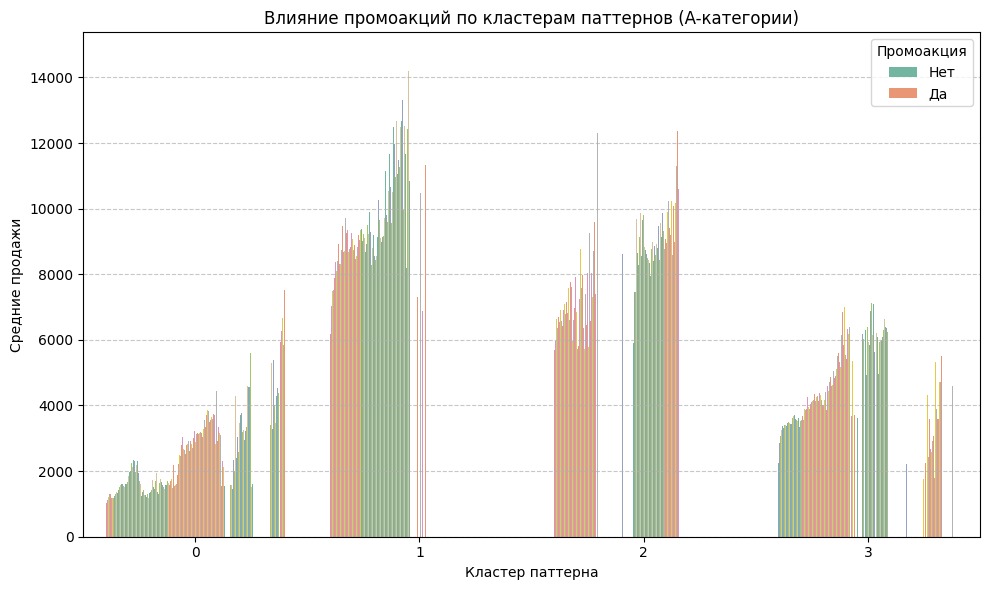


Средние продажи по кластерам и промоакциям:
onpromotion               0       1       2       3       4       5       6       7       8       9       10      11      12      13      14      15      16      17      18      19      20      21      22      23      24      25      26      27      28      29      30      31      32      33      34      35      36      37      38      39      40      41      42      43      44      45      46      47      48      49      50      51      52      53      54      55      56      57      58      59      60      61      62      63      64      65      66      67      68      69      70      71      72       73      74      75      76      77      78       79      80      81       82      83      84      85      86       87      88      89      90      91      92      93      94      95      96      97       98      99      100     101     102     103     104     105     106      107     108     109     110      111      112     113     114      

In [136]:
# График: продажи по кластерам паттернов и наличию промо
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_A,
    x='sales_pattern_cluster',
    y='sales',
    hue='onpromotion',
    errorbar=None,
    palette='Set2'
)
plt.title('Влияние промоакций по кластерам паттернов (A-категории)')
plt.ylabel('Средние продажи')
plt.xlabel('Кластер паттерна')
plt.legend(title='Промоакция', labels=['Нет', 'Да'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Таблица: средние продажи
promo_effect = df_A.groupby(['sales_pattern_cluster', 'onpromotion'])['sales'].mean().unstack()
print("\nСредние продажи по кластерам и промоакциям:")
print(promo_effect)

In [140]:
# Агрегация: среднее и количество по кластеру и промо
promo_grouped = df_A.groupby(['sales_pattern_cluster', 'onpromotion'])['sales'].agg(
    mean_sales='mean',
    count_sales='count'
).reset_index()

# Поворачиваем таблицу: промоакции в колонки
promo_pivot = promo_grouped.pivot(
    index='sales_pattern_cluster',
    columns='onpromotion',
    values=['mean_sales', 'count_sales']
)

# Сглаживаем мультииндекс колонок
promo_pivot.columns = [
    f'{stat}_promo_{promo}'
    for stat, promo in promo_pivot.columns
]

# Процентный рост продаж при промоакции:
promo_pivot['promo_lift_pct'] = (
    (promo_pivot['mean_sales_promo_1'] / promo_pivot['mean_sales_promo_0'] - 1) * 100
)

result = promo_pivot[[
    'mean_sales_promo_0',
    'mean_sales_promo_1',
    'promo_lift_pct'
]].round(2)

print("Эффект промоакций по кластерам паттернов:")
print(result)

Эффект промоакций по кластерам паттернов:
                       mean_sales_promo_0  mean_sales_promo_1  promo_lift_pct
sales_pattern_cluster                                                        
0                                  523.93             1028.86           96.37
1                                 5814.36             6194.26            6.53
2                                 2711.96             5693.01          109.92
3                                 2232.95             2695.37           20.71


Промоакции (скидки, акции) работают — но не везде одинаково.

*  Кластер 2 — промоакции работают ЛУЧШЕ ВСЕГО
Продажи удваиваются (+110%)!
Это сезонные товары (PRODUCE — овощи, фрукты и т.п.).
Вывод: когда идёт акция на такие товары — спрос взлетает.   
→ Нужно обязательно учитывать промоакции для этого кластера.
*  Кластер 0 — промоакции работают ОЧЕНЬ ХОРОШО
Продажи растут почти в 2 раза (+96%).
Это товары с низким спросом (например, в небольших магазинах).
Вывод: акции оживляют слабый спрос.    
→ Тоже обязательно учитывать.
*  Кластер 3 — промоакции работают УМЕРЕННО
Рост на 21% — заметно, но не взрыв.
Это смешанные товары.    
Вывод: акции полезны, но не критичны.
*  Кластер 1 — промоакции почти НЕ работают
Рост всего на 6.5% — почти ничего.
Это флагманские магазины + базовые товары (GROCERY I, BEVERAGES).
Люди и так всё покупают — акции почти не влияют.   
Вывод: можно не тратить усилия на моделирование промо для этих рядов.

-----------------------------------------------------------------
Промоакции — мощный инструмент, но только для определённых товаров и магазинов.

Для кластеров 0 и 2 — промоакции усиливают спрос в 2 раза → их обязательно нужно учитывать в модели.
Для кластера 1 — промоакции почти бесполезны → можно игнорировать или учитывать слабо.
Для кластера 3 — умеренное влияние → учитывать, но без фанатизма.